In [ ]:
# original file : https://github.com/keflavich/brick-jwst-2221/blob/main/brick2221/reduction/saturated_star_finding.py
import glob
from astropy.io import fits
from scipy.ndimage import label, find_objects, center_of_mass, sum_labels
from astropy.modeling.fitting import LevMarLSQFitter
from jwst.datamodels import dqflags
import matplotlib.pyplot as plt
try:
    # version >=1.7.0, doesn't work: the PSF is broken (https://github.com/astropy/photutils/issues/1580?)
    from photutils.psf import PSFPhotometry, IterativePSFPhotometry, SourceGrouper
except:
    # version 1.6.0, which works
    from photutils.psf import BasicPSFPhotometry as PSFPhotometry, IterativelySubtractedPSFPhotometry as IterativePSFPhotometry, DAOGroup as SourceGrouper
try:
    from photutils.background import MMMBackground, MADStdBackgroundRMS, MedianBackground, Background2D, LocalBackground
except:
    from photutils.background import MMMBackground, MADStdBackgroundRMS, MedianBackground, Background2D
    from photutils.background import MMMBackground as LocalBackground


from tqdm.notebook import tqdm
from tqdm import tqdm
from astropy import wcs
from astropy.wcs import WCS
import numpy as np
from scipy import ndimage
from astropy.table import Table, QTable
from astropy import table
from astropy import log
from filtering import get_filtername, get_fwhm
import functools
import requests
import urllib3
def get_psf(header, path_prefix='.'):
    if header['INSTRUME'].lower() == 'nircam':
        psfgen = stpsf.NIRCam()
        fwhm, fwhm_pix = get_fwhm(header, instrument_replacement='NIRCam')
    elif header['INSTRUME'].lower() == 'miri':
        psfgen = stpsf.MIRI()
        fwhm, fwhm_pix = get_fwhm(header, instrument_replacement='MIRI')
    instrument = header['INSTRUME']
    filtername = get_filtername(header)
    try:
        module = header['MODULE']
    except KeyError:
        module = header['DETECTOR']
    detector = header['DETECTOR']

    ww = wcs.WCS(header)
    try:
        assert ww.wcs.cdelt[1] != 1, "This is not a valid WCS!!! CDELT is wrong!! how did this HAPPEN!?!?"
    except AssertionError as ex:
        print(ex) 
        print("ignoring WCS failure so check that stuff is right...")

    psfgen.filter = filtername
    obsdate = header['DATE-OBS']

    with open(os.path.expanduser('~/.mast_api_token'), 'r') as fh:
        api_token = fh.read().strip()

    npsf = 16
    oversample = 2
    fov_pixels = 512
    if detector == 'NRCALONG':
        detector = 'nrca5'
    elif detector == 'NRCBLONG':
        detector = 'nrcb5'
    if detector.lower() == 'mirimage':
        detector = 'mirim'
    psf_fn = f'{path_prefix}/{instrument.lower()}_{detector.lower()}_{filtername.lower()}_fovp{fov_pixels}_samp{oversample}_npsf{npsf}.fits'

    if module == 'merged':
        project_id = header['PROGRAM'][1:5]
        obs_id = header['OBSERVTN'].strip()
        merged_psf_fn = f'{basepath}/psfs/{filtername.upper()}_{project_id}_{obs_id}_merged_PSFgrid.fits'
        if os.path.exists(psf_fn):
            psf_fn = merged_psf_fn
        else:
            print("stpsf is being used for merged data because merged PSF does not exist", flush=True)

    if os.path.exists(str(psf_fn)):
        # As a file
        log.info(f"Loading grid from psf_fn={psf_fn}")
        big_grid = to_griddedpsfmodel(psf_fn)  # file created 2 cells above
        if isinstance(big_grid, list):
            print(f"PSF IS A LIST OF GRIDS!!!", flush=True)
            big_grid = big_grid[0]
    else:
        log.info(f'PSF file {psf_fn} does not exist; downloading from MAST')
        from astroquery.mast import Mast

        print(f"Attempting to load PSF for {obsdate}")
        try:
            Mast.login(api_token.strip())
            os.environ['MAST_API_TOKEN'] = api_token.strip()

            psfgen.load_wss_opd_by_date(f'{obsdate}T00:00:00')
        except (urllib3.exceptions.ReadTimeoutError, requests.exceptions.ReadTimeout, requests.HTTPError) as ex:
            print(f"Failed to build PSF: {ex}")
        except Exception as ex:
            print("psfgen load_wss_opd_by_date failed")
            print(ex)

        log.info(f"starfinding: Calculating grid for psf_fn={psf_fn}")
        # https://github.com/spacetelescope/stpsf/blob/cc16c909b55b2a26e80b074b9ab79ed9a312f14c/stpsf/stpsf_core.py#L640
        # https://github.com/spacetelescope/stpsf/blob/cc16c909b55b2a26e80b074b9ab79ed9a312f14c/stpsf/gridded_library.py#L424
        big_grid = psfgen.psf_grid(num_psfs=npsf, oversample=oversample,
                                   all_detectors=True, fov_pixels=fov_pixels,
                                   outdir=path_prefix,
                                   save=True, outfile=None, overwrite=True)
        # now the PSF should be written
        assert glob.glob(psf_fn.replace(".fits", "*"))
        if isinstance(big_grid, list):
            print(f"PSF FROM PSF_GEN IS A LIST OF GRIDS!!!", flush=True)
            big_grid = big_grid[0]
            # if we really want to get this right, we need to create a new grid of PSF models
            # that is some sort of average of the PSF model grid.
            # There's no way to do it _right_ right without going back to the original data,
            # which is untenable with this approach.  It's a huge project.

    return big_grid
def debug_wrap(function):
    @functools.wraps(function)
    def wrapper(*args, **kwargs):
        print(function.__name__, flush=True)
        return function(*args, **kwargs)
    return wrapper

import os
#os.environ['stpsf_PATH'] = '/orange/adamginsburg/jwst/stpsf-data/'
import stpsf
from stpsf.utils import to_griddedpsfmodel



def get_saturated_stars(fitsdata,path_prefix='/orange/adamginsburg/jwst/w51/psfs/', pad=30, size=None, min_sep_from_edge=5, edge_npix=10000, mask_buffer=1, plot=True, rindsz=3):
    header = fitsdata[0].header
    data = fitsdata['SCI'].data
    data[np.isnan(fitsdata['VAR_POISSON'].data)] = 0
    dq = fitsdata['DQ'].data
    saturated = (dq & dqflags.pixel['SATURATED'])>0 
    sources, nsource = label(saturated)
    sizes = sum_labels(saturated, sources, np.arange(nsource)+1)
    msfe = min_sep_from_edge

    # which sources are edge sources?  Anything w/ more than edge_npix contiguous "saturated" pixels
    # add +1 because 0 is the non-saturated zone that we've excluded
    edge_ids = np.where(sizes > edge_npix)[0] + 1
    edge_mask = np.isin(sources, edge_ids)
    saturated = saturated & (~ndimage.binary_dilation(edge_mask, iterations=msfe))


    big_grid = get_psf(header, path_prefix=path_prefix)
    ww = wcs.WCS(header)

    # We force the centroid to be fixed b/c the fitter doesn't do a great job with this...
    # ....this is not optimal...
    #big_grid.fixed['x_0'] = True
    #big_grid.fixed['y_0'] = True

    # daogroup should be set super high to avoid fitting lots of "stars"... if there are a lot of saturated pixels near each other, they're probably all junk
    daogroup = SourceGrouper(min_separation=25)

    resid = data

    results = []

    lmfitter = LevMarLSQFitter()
    # def levmarverbosewrapper(self, *args, **kwargs):
    #     print("Running lmfitter")
    #     log.info(f"Running lmfitter with args {args} and kwargs {kwargs}")
    #     return self(*args, **kwargs)
    # #lmfitter.__call__ = levmarverbosewrapper
    # lmfitter._run_fitter = levmarverbosewrapper

    if header['INSTRUME'].lower() == 'nircam':
        psfgen = stpsf.NIRCam()
        fwhm, fwhm_pix = get_fwhm(header, instrument_replacement='NIRCam')
    elif header['INSTRUME'].lower() == 'miri':
        psfgen = stpsf.MIRI()
        fwhm, fwhm_pix = get_fwhm(header, instrument_replacement='MIRI')

    
    slices = find_objects(saturated)
    
        # define pad/size/fwhm_pix (choose sensible defaults if not already set)
    size = pad = 81

    index = 0
    print(f"Found {nsource-1} saturated sources to process", flush=True)
    for i in range(nsource-1):
        if True:
            # get the center of pixels with this label
            
            com = center_of_mass(saturated, labels=sources, index=i+1)
            # center_of_mass can return (nan, nan) for degenerate labels; guard against that
            if com is None:
                print(f"Source {i+1}: center_of_mass returned None; skipping", flush=True)
                continue
            yf, xf = com
            if not (np.isfinite(yf) and np.isfinite(xf)):
                print(f"Source {i+1}: center_of_mass returned NaN or infinite values ({yf}, {xf}); skipping", flush=True)
                continue
            ycen = int(round(yf))
            xcen = int(round(xf))
            print(f"Source {i+1}: center at (x, y) = ({xcen}, {ycen})")
            y0 = int(max(0, ycen - pad))
            y1 = int(min(data.shape[0], ycen + pad))
            x0 = int(max(0, xcen - pad))
            x1 = int(min(data.shape[1], xcen + pad))
            size_saturated = int(np.sqrt(sum_labels(saturated, labels=sources, index=i+1))/2)
            area_saturated = sum_labels(saturated, labels=sources, index=i+1)
            cutout = data[y0:y1, x0:x1]
            init_params = QTable()
            init_params['x'] = [xcen - x0]
            init_params['y'] = [ycen - y0]
            cutout[np.isnan(cutout)] = 0.0
            # if isinstance(grid, list):
            #     print(f"Grid is a list: {grid}")
            #     psf_model = WrappedPSFModel(grid[0])
            #     dao_psf_model = grid[0]
            # else:

            #psf_model = WrappedPSFModel(grid, stampsz=(size,size))

           

           
            psfphot = PSFPhotometry(
                                        localbkg_estimator=LocalBackground(15, 30),
                                        fitter=lmfitter,
                                        psf_model=big_grid,
                                        fit_shape=size,
                                        aperture_radius=15*fwhm_pix)
            low_x  = xcen - x0 - size_saturated
            high_x = xcen - x0 + size_saturated
            low_y  = ycen - y0 - size_saturated
            high_y = ycen - y0 + size_saturated

            # get the underlying model and set bounds there
            model = getattr(psfphot, "psf_model", None)
            if model is None:
                raise RuntimeError("psfphot.psf_model is None — can't set parameter bounds")

            for pname, bounds in (("x_0", (low_x, high_x)), ("y_0", (low_y, high_y))):
                if hasattr(model, pname):
                    param = getattr(model, pname)
                    # try the supported API first
                    try:
                        param.bounds = bounds
                        print(f"Set {pname}.bounds = {bounds}")
                    except Exception:
                        # fallback (private attribute) if necessary
                        try:
                            param._bounds = bounds
                            print(f"Set {pname}._bounds = {bounds} (fallback)")
                        except Exception:
                            print(f"Could not set bounds for {pname}; parameter object: {param}")
                else:
                    print(f"Model does not have parameter '{pname}'; param_names={getattr(model,'param_names',None)}")
            # let x_0 be bounds at saturated pixels
            #psfphot.x_0.bounds = (xcen - x0 - size_saturated , xcen - x0 + size_saturated)
            #psfphot.y_0.bounds = (ycen - y0 - size_saturated, ycen - y0 + size_saturated)
            saturated_mask = saturated[y0:y1, x0:x1]
            


            # expand a few pixels of saturated area to be masked
            saturated_mask_expanded = ndimage.binary_dilation(saturated_mask, iterations=mask_buffer)
            mask = np.logical_or(cutout==0, np.isnan(cutout), saturated_mask_expanded)
            try:
                result = psfphot(cutout, init_params=init_params, mask=mask)
            except Exception as ex:
                print(f"PSF photometry failed for source {i+1} at (x,y)=({xcen},{ycen}): {ex}", flush=True)
                continue
            result['skycoord_fit'] = ww.pixel_to_world(result['x_fit'], result['y_fit'])
            
            result['xcentroid'] = result['x_fit'] + x0
            result['ycentroid'] = result['y_fit'] + y0
            
            result.pprint(max_width=-1)

            ny = cutout.shape[0]
            nx = cutout.shape[1]
            model_image = np.zeros_like(cutout)
          

           
            



            for x_fit, y_fit, flux in zip(result['x_fit'], result['y_fit'], result['flux_fit']):
                # Make a local grid around the source
                if np.isnan(flux):
                    raise ValueError("Flux is NaN; cannot build PSF model image")
                y, x = np.mgrid[0:ny, 0:nx]
                #psf_eval = big_grid(x, y, flux=flux, x_0=x0, y_0=y0)  # works for analytic PSF
                psf_eval = big_grid(x-x_fit, y-y_fit) * flux  # works for GriddedPSFModel
                # cut psf_eval to the image size
                model_image += psf_eval[0:ny, 0:nx]
            
            threshold_image = np.zeros_like(cutout)

            #count the number of pixels above local background in the model_image
            threshold = np.nanpercentile(cutout, 99)
            threshold_image[model_image>threshold]=1
            num_pixels_above_threshold = np.nansum(threshold_image)
            print(np.nanmax(model_image), flush=True)
            print(f"Number of pixels above threshold ({threshold}): {num_pixels_above_threshold}", flush=True)
           
            if len(result) > 0:
                flux = result['flux_fit'][0]
                fluxerr = result['flux_err'][0]
                snr = result['flux_fit'][0] / result['flux_err'][0]
                qfit = result['qfit'][0]
                cfit = result['cfit'][0]

            if plot:
                fig = plt.figure(figsize=(12,12))
                ax1 = fig.add_subplot(2,3,1)
                ax1.imshow(cutout, origin='lower', cmap='viridis', vmin=0, vmax=np.nanpercentile(cutout, 99))
                ax1.set_title('Cutout')
                ax2 = fig.add_subplot(2,3,2)
                ax2.set_title('Model')
                ax2.imshow(model_image, origin='lower', cmap='viridis', vmin=0, vmax=np.nanpercentile(cutout, 99))
                ax3 = fig.add_subplot(2,3,3)
                resid_image = cutout - model_image
                ax3.imshow(resid_image, origin='lower', cmap='viridis', vmin=0, vmax=np.nanpercentile(cutout, 99))
                ax3.set_title('Residual')
                ax4 = fig.add_subplot(2,3,4)
                ax4.imshow(mask, origin='lower', cmap='gray')
                ax4.set_title('Mask')
                ax5 = fig.add_subplot(2,3,5)
                ax5.imshow(threshold_image, origin='lower', cmap='gray')
                ax5.set_title('Thresholded Model Pixels')
                # print flux, fluxerr, snr, cfit in the title
                if len(result) > 0:
                    
                
                    ax1.set_title(f'Cutout\nFlux={flux:.2f}, FluxErr={fluxerr:.2f}, SNR={snr:.2f}, qfit={qfit:.2f}, cfit={cfit:.2f}')

                plt.show()
                plt.close()
            
            # check whether the pixels with dqflag = saturated are also flagged as HOT, DEAD, and RC
            # this is a sanity check to make sure that the saturated pixels are not being used in the fit
            idx_saturated_in_cutout = (dq[y0:y1, x0:x1] & dqflags.pixel['SATURATED']) > 0
            saturated_dqflags = dq[y0:y1, x0:x1][idx_saturated_in_cutout]
            if np.any((saturated_dqflags & dqflags.pixel['HOT'])!=0):
                print(f"Warning: Some saturated pixels are flagged as HOT; skipping source", flush=True)
                continue
            if np.any((saturated_dqflags & dqflags.pixel['DEAD'])!=0):
                print(f"Warning: Some saturated pixels are flagged as DEAD; skipping source", flush=True)
                continue
            #if np.any((saturated_dqflags & dqflags.pixel['RC'])!=0):
            #    print(f"Warning: Some saturated pixels are flagged as RC; skipping source", flush=True)
            #    continue
            
            
            
            # compare FWHM of the model and the size of saturated pixels
            #if area_saturated > num_pixels_above_threshold:
            #    print(f"Warning: Saturated mask area ({area_saturated}) is larger than number of pixels above threshold ({num_pixels_above_threshold}); skipping source", flush=True)
            #    continue
                
            # process the result
            if result is not None and np.isfinite(fluxerr) and snr > 1 and flux > 0:
                print(f"Accepting source {i+1} with flux={flux}, fluxerr={fluxerr}, snr={snr}", flush=True)
                if index == 0:
                    base_tab = result
                else:
                    base_tab = table.vstack([base_tab, result])
                
                index += 1
            else:
                print(f"Skipping source {i+1} due to non-finite flux error or low SNR", flush=True)
                print(f"  fluxerr={fluxerr}, snr={snr}", flush=True)
            
    # if base_tab is not defined, return None
    # this happens if no saturated stars are found
    if index == 0:
        print('No saturated stars found after processing all sources', flush=True)
        return None
    else:
        return base_tab

def remove_saturated_stars(filename, save_suffix='_unsatstar', **kwargs):
    print(f"Removing saturated stars from {filename}", flush=True)
    fh = fits.open(filename)
    data = fh['SCI'].data

    # there are examples, especially in Faaaaa405, where the variance is NaN but the value
    # is negative
    print(f"Setting NaN variance to 0", flush=True)
    #data[np.isnan(fh['VAR_POISSON'].data)] = 0

    header = fh[0].header
    if 'CRPIX1' not in header:
        header.update(wcs.WCS(fh['SCI'].header).to_header())
    print("Running get_saturated_stars", flush=True)
    satstar_table = get_saturated_stars(fh,)
    if satstar_table is not None:
        satstar_table.meta.update(header)
        print("Finished get_saturated_stars", flush=True)

        satstar_table.write(filename.replace(".fits", '_satstar_catalog_newnewnewnew.fits'), overwrite=True)
        print(f"Saved saturated star catalog to {filename.replace('.fits', '_satstar_catalog_newnewnewnew.fits')}", flush=True)
    else:
        print("No saturated stars found", flush=True)
        return
        
    

    

def main(filt='F480M'):

  
    if filt in ['F140M', 'F162M', 'F182M', 'F187N', 'F210M', 'F335M', 'F360M', 'F405N', 'F410M', 'F480M']:
        modules = ('nrca', 'nrcb')
    else:
        modules = ('mirim',) 
    for module in modules:
        if filt in ['F140M', 'F162M', 'F182M', 'F187N', 'F210M', 'F335M', 'F360M', 'F405N', 'F410M', 'F480M']:
            globlist = glob.glob(f"/orange/adamginsburg/jwst/w51/{filt}/pipeline/*{module}*align*crf.fits")
        else:
            globlist = glob.glob(f"/orange/adamginsburg/jwst/w51/{filt}/pipeline/*miri_*_crf.fits")
        for i, fn in enumerate(globlist):
            print()
            print(fn)
            if i<=4:
                remove_saturated_stars(fn, plot=True)

    #for module in ('nrca', 'nrcb', 'merged'):
    #    for fn in glob.glob(f"/orange/adamginsburg/jwst/w51/F*/pipeline/*{module}*crf.fits"):
    #        print()
    #        print(fn)
    #        remove_saturated_stars(fn, verbose=True)



In [32]:
nircam_filters = ['F560W']


Processing filter F560W

/orange/adamginsburg/jwst/w51/F560W/pipeline/jw06151-o002_t001_miri_f560w_12_o002_crf.fits
Removing saturated stars from /orange/adamginsburg/jwst/w51/F560W/pipeline/jw06151-o002_t001_miri_f560w_12_o002_crf.fits
Setting NaN variance to 0


Set OBSGEO-B to    -3.703479 from OBSGEO-[XYZ].
Set OBSGEO-H to 1291157459.541 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
2025-11-12 16:15:57,192 - stpipe - WARNING - FITSFixedWarning: 'obsfix' made the change 'Set OBSGEO-L to   -34.539056 from OBSGEO-[XYZ].
Set OBSGEO-B to    -3.703479 from OBSGEO-[XYZ].
Set OBSGEO-H to 1291157459.541 from OBSGEO-[XYZ]'.
2025-11-12 16:15:57,198 - stpipe - WARNING - Some non-standard WCS keywords were excluded: A_ORDER, A_0_2, A_0_3, A_0_4, A_1_1, A_1_2, A_1_3, A_2_0, A_2_1, A_2_2, A_3_0, A_3_1, A_4_0, B_ORDER, B_0_2, B_0_3, B_0_4, B_1_1, B_1_2, B_1_3, B_2_0, B_2_1, B_2_2, B_3_0, B_3_1, B_4_0, AP_ORDER, AP_0_1, AP_0_2, AP_0_3, AP_0_4, AP_1_0, AP_1_1, AP_1_2, AP_1_3, AP_2_0, AP_2_1, AP_2_2, AP_3_0, AP_3_1, AP_4_0, BP_ORDER, BP_0_1, BP_0_2, BP_0_3, BP_0_4, BP_1_0, BP_1_1, BP_1_2, BP_1_3, BP_2_0, BP_2_1, BP_2_2, BP_3_0, BP_3_1, BP_4_0 Use the ``relax`` kwarg to control this.


Running get_saturated_stars


2025-11-12 16:15:57,313 - stpipe - WARNING - FITSFixedWarning: The WCS transformation has more axes (2) than the image it is associated with (0)


This is not a valid WCS!!! CDELT is wrong!! how did this HAPPEN!?!?
ignoring WCS failure so check that stuff is right...


2025-11-12 16:15:57,370 - stpipe - INFO - Loading grid from psf_fn=/orange/adamginsburg/jwst/w51/psfs//miri_mirim_f560w_fovp512_samp2_npsf16.fits


INFO: Loading grid from psf_fn=/orange/adamginsburg/jwst/w51/psfs//miri_mirim_f560w_fovp512_samp2_npsf16.fits [unknown]
Found 9 saturated sources to process
Source 1: center at (x, y) = (234, 66)
Set x_0.bounds = (78, 84)
Set y_0.bounds = (63, 69)
PSF photometry failed for source 1 at (x,y)=(234,66): Source at (81, 66) is completely masked. Remove the source from init_params or correct the input mask.
Source 2: center at (x, y) = (386, 316)
Set x_0.bounds = (79, 83)
Set y_0.bounds = (79, 83)
 id group_id group_size     local_bkg     x_init y_init     flux_init            x_fit             y_fit            flux_fit            x_err               y_err              flux_err      npixfit         qfit        cfit flags              skycoord_fit                 xcentroid         ycentroid     
                                                                                                                                                                                                        

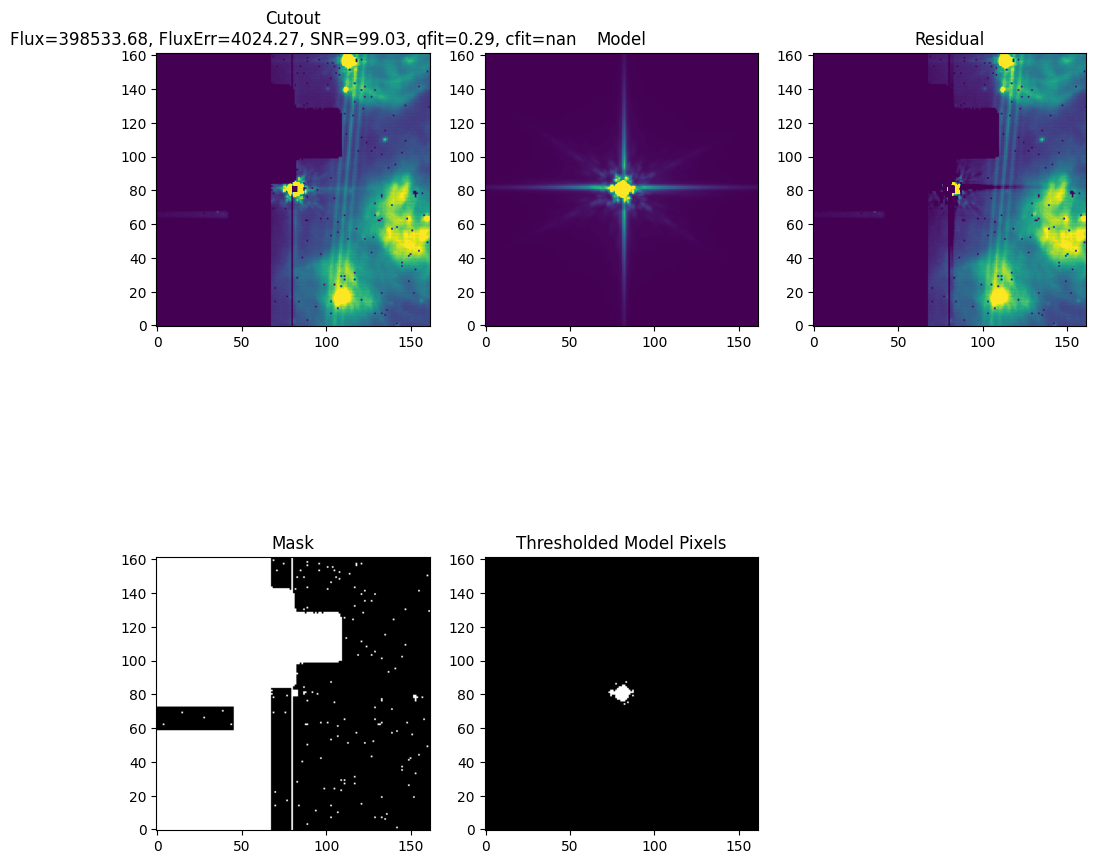

Accepting source 2 with flux=398533.6774013981, fluxerr=4024.2682574346863, snr=99.0325822999304
Source 3: center at (x, y) = (742, 335)
Set x_0.bounds = (80, 82)
Set y_0.bounds = (80, 82)


2025-11-12 16:15:59,789 - stpipe - WARNING - One or more fit(s) may not have converged. Please check the "flags" column in the output table.


 id group_id group_size     local_bkg     x_init y_init     flux_init            x_fit             y_fit            flux_fit     x_err y_err flux_err npixfit        qfit        cfit flags              skycoord_fit                 xcentroid         ycentroid    
                                                                                                                                                                                                           deg,deg                                                   
--- -------- ---------- ----------------- ------ ------ ------------------ ----------------- ----------------- ----------------- ----- ----- -------- ------- ------------------ ---- ----- ------------------------------------- ----------------- -----------------
  1        1          1 41.30719184875488     81     81 108599.53005591693 80.90622920323453 80.87566586040035 3709.974748436192   nan   nan      nan    6496 11.664834519856974  nan     9 290.89696062104593,14.5135

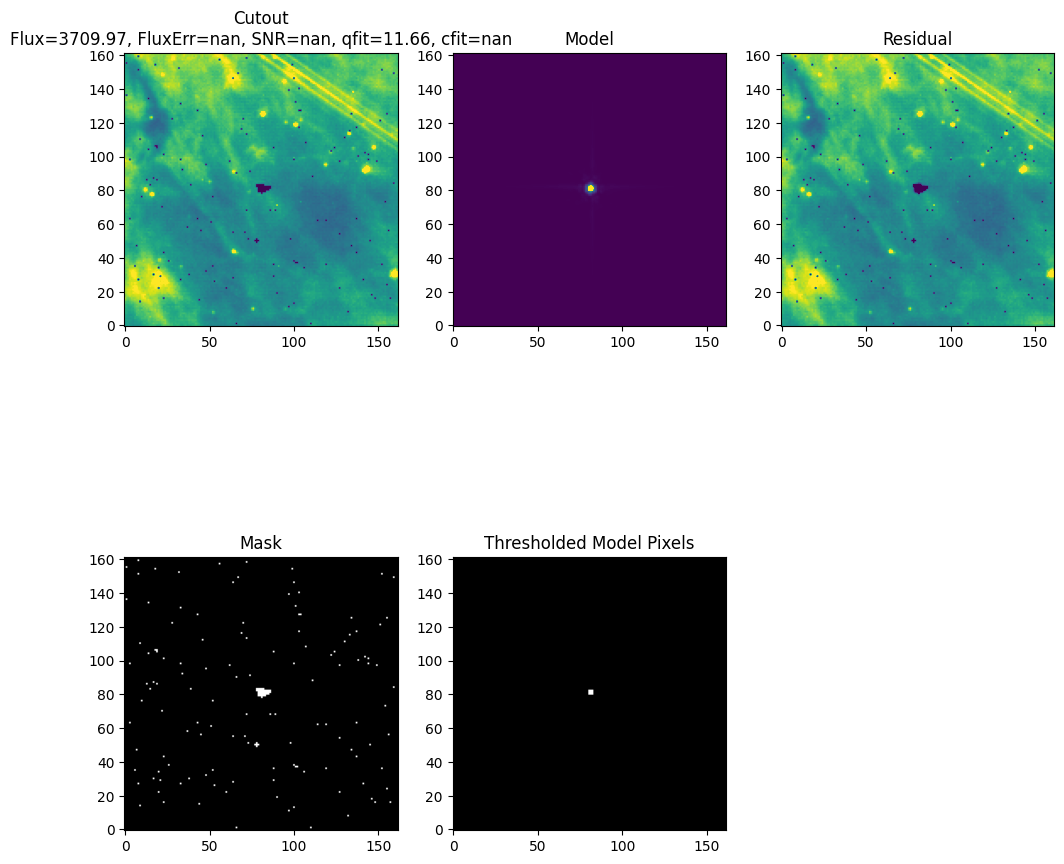

Source 4: center at (x, y) = (816, 470)
Set x_0.bounds = (80, 82)
Set y_0.bounds = (80, 82)


2025-11-12 16:16:01,156 - stpipe - WARNING - One or more fit(s) may not have converged. Please check the "flags" column in the output table.


 id group_id group_size     local_bkg     x_init y_init    flux_init           x_fit             y_fit            flux_fit      x_err y_err flux_err npixfit        qfit        cfit flags              skycoord_fit                 xcentroid        ycentroid    
                                                                                                                                                                                                          deg,deg                                                  
--- -------- ---------- ----------------- ------ ------ ---------------- ----------------- ----------------- ------------------ ----- ----- -------- ------- ------------------ ---- ----- ------------------------------------- ----------------- ----------------
  1        1          1 40.29935836791992     81     81 90573.5526100563 81.94857194145875 81.13832457931302 -9995.928933757712   nan   nan      nan    6489 -5.274695567918924  nan    13 290.89697963241673,14.51354182404

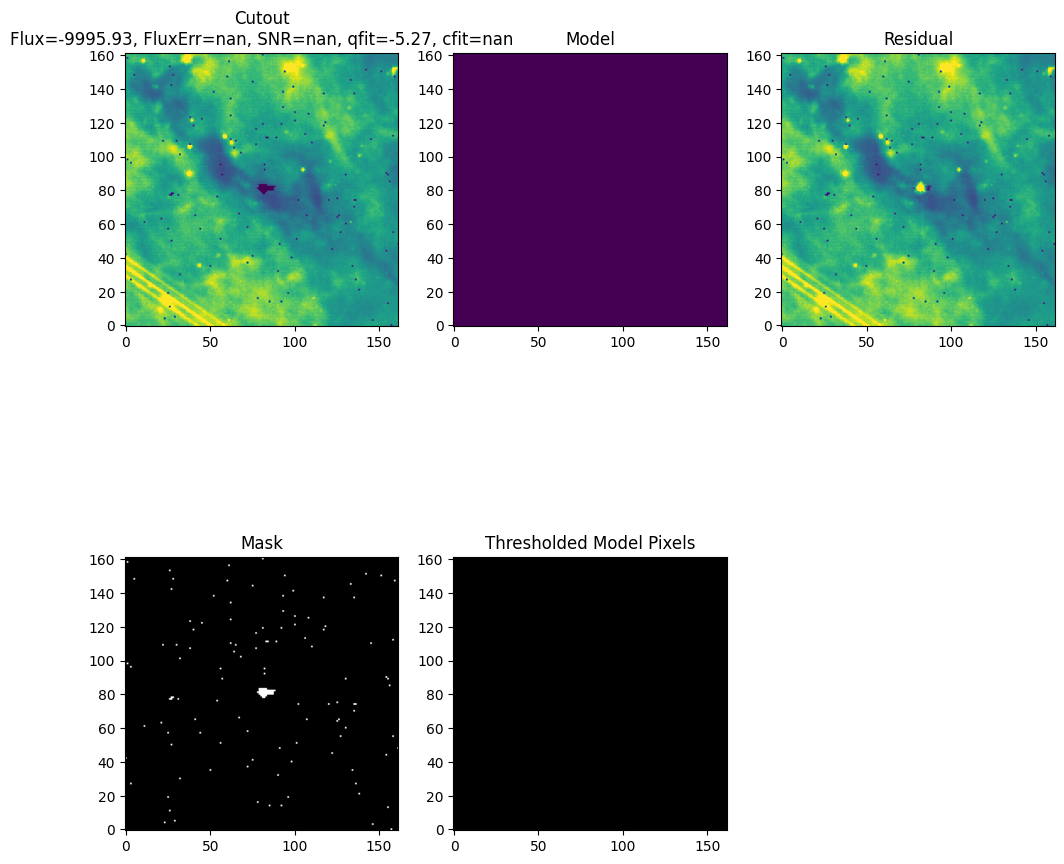

Source 5: center at (x, y) = (449, 609)
Set x_0.bounds = (57, 105)
Set y_0.bounds = (57, 105)
 id group_id group_size   local_bkg    x_init y_init     flux_init           x_fit             y_fit            flux_fit            x_err              y_err             flux_err     npixfit         qfit        cfit flags              skycoord_fit                xcentroid         ycentroid    
                                                                                                                                                                                                                                            deg,deg                                                  
--- -------- ---------- -------------- ------ ------ ----------------- ----------------- ----------------- ------------------ ------------------ ------------------ ----------------- ------- ------------------- ---- ----- ------------------------------------- ---------------- -----------------
  1        1          1 

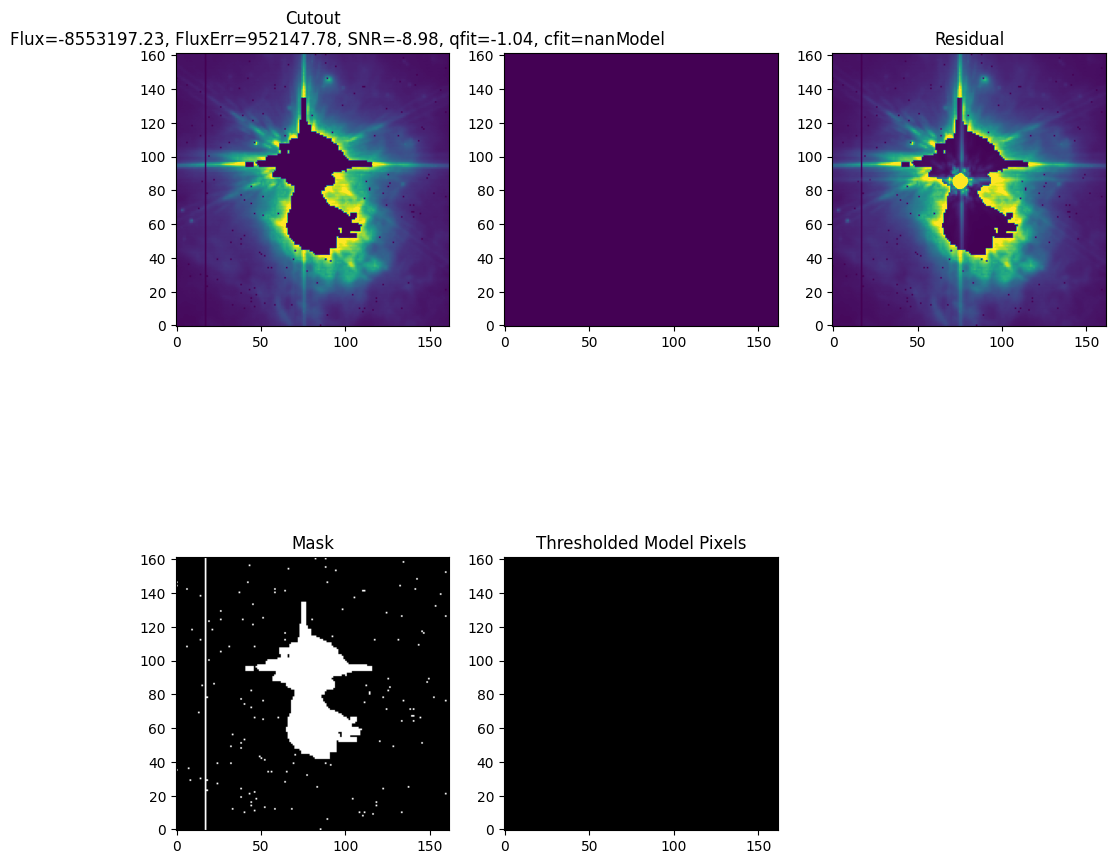

Skipping source 5 due to non-finite flux error or low SNR
  fluxerr=952147.7847196338, snr=-8.983056379149765
Source 6: center at (x, y) = (411, 623)
Set x_0.bounds = (80, 82)
Set y_0.bounds = (80, 82)
 id group_id group_size     local_bkg      x_init y_init     flux_init          x_fit             y_fit            flux_fit             x_err               y_err             flux_err     npixfit        qfit       cfit flags             skycoord_fit                 xcentroid         ycentroid    
                                                                                                                                                                                                                                              deg,deg                                                   
--- -------- ---------- ------------------ ------ ------ ----------------- ---------------- ----------------- ------------------ ------------------- -------------------- ---------------- ------- ---------

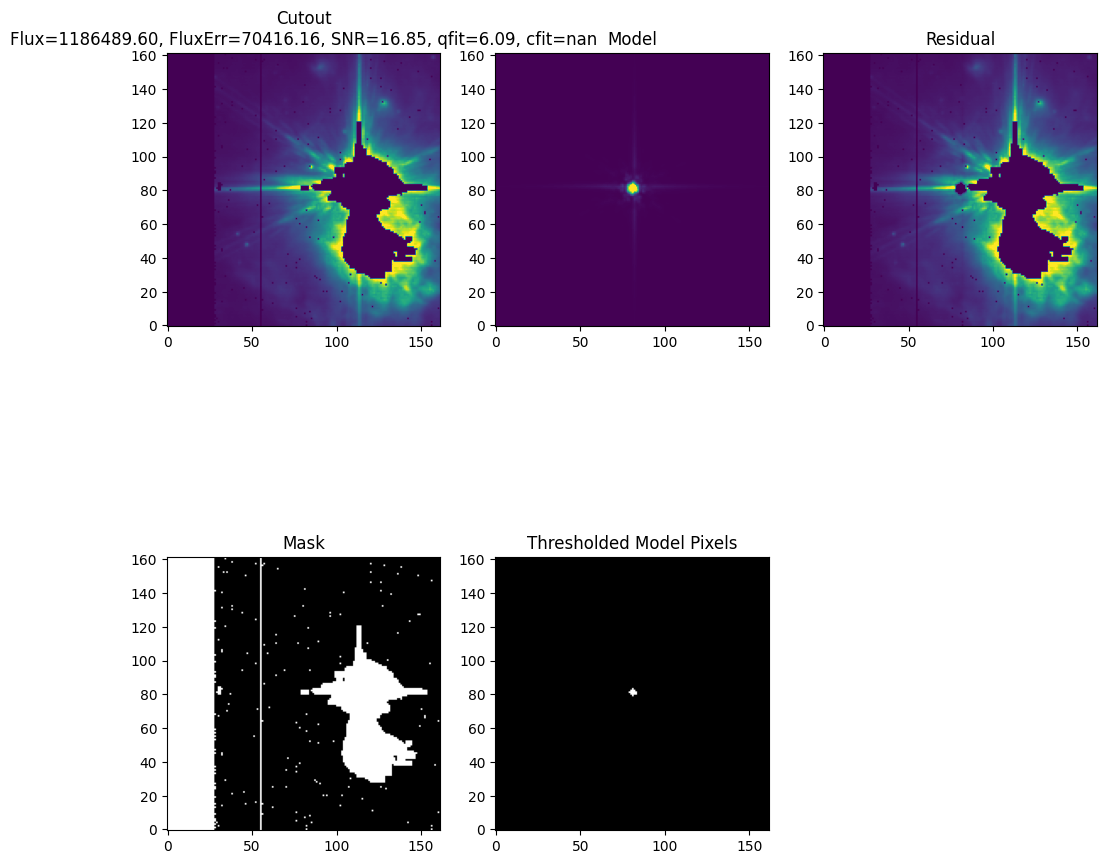

Accepting source 6 with flux=1186489.6009848132, fluxerr=70416.1612904486, snr=16.84967739281964


2025-11-12 16:16:04,547 - stpipe - WARNING - MergeConflictWarning: Cannot merge meta key 'date' types <class 'str'> and <class 'str'>, choosing date='2025-11-12 16:16:04 EST'


Source 7: center at (x, y) = (781, 671)
Set x_0.bounds = (78, 84)
Set y_0.bounds = (78, 84)
 id group_id group_size     local_bkg      x_init y_init     flux_init           x_fit             y_fit             flux_fit             x_err              y_err             flux_err      npixfit        qfit       cfit flags             skycoord_fit                xcentroid         ycentroid    
                                                                                                                                                                                                                                                deg,deg                                                  
--- -------- ---------- ------------------ ------ ------ ------------------ ---------------- ----------------- ------------------- ------------------- ------------------ ------------------ ------- ----------------- ---- ----- ----------------------------------- ----------------- -----------------
  1        1  

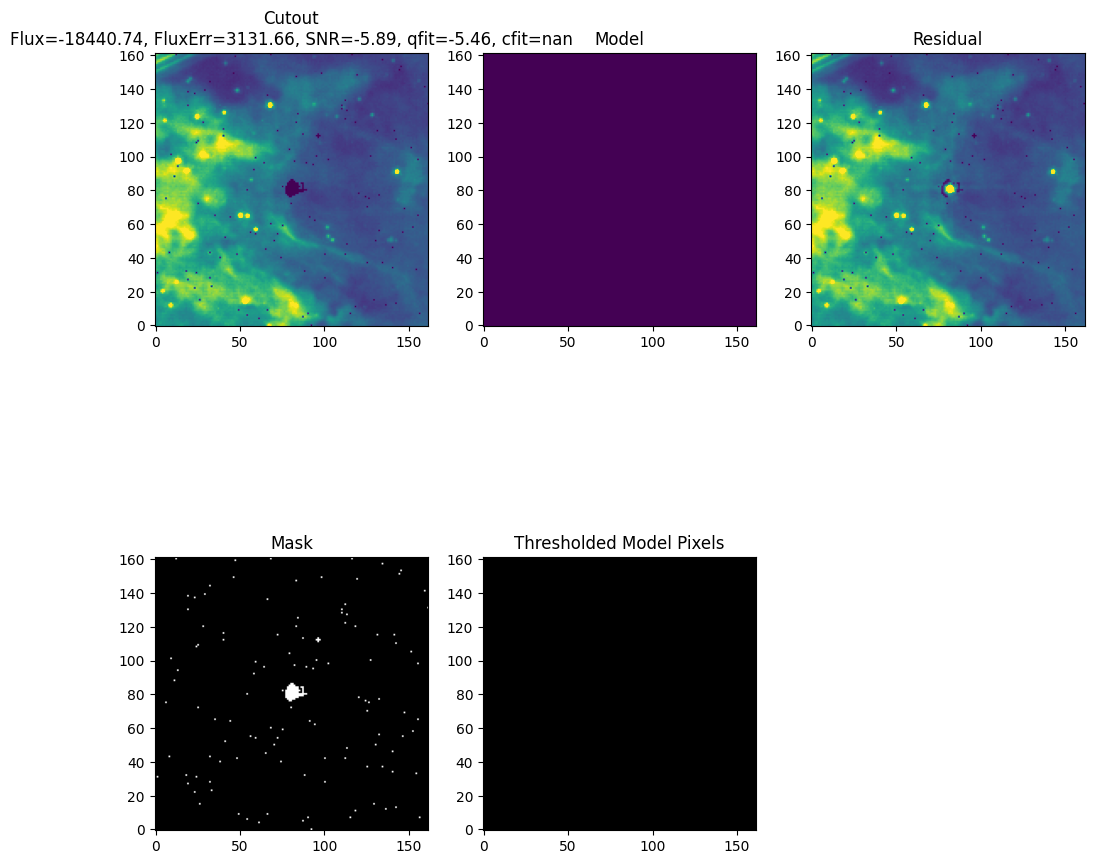

Source 8: center at (x, y) = (599, 730)
Set x_0.bounds = (78, 84)
Set y_0.bounds = (78, 84)
 id group_id group_size     local_bkg      x_init y_init     flux_init           x_fit             y_fit            flux_fit            x_err             y_err           flux_err     npixfit       qfit       cfit flags             skycoord_fit                 xcentroid         ycentroid    
                                                                                                                                                                                                                                         deg,deg                                                   
--- -------- ---------- ------------------ ------ ------ ----------------- ----------------- ----------------- ------------------ ------------------ ---------------- ---------------- ------- ---------------- ---- ----- ------------------------------------ ----------------- -----------------
  1        1          1 138.4305

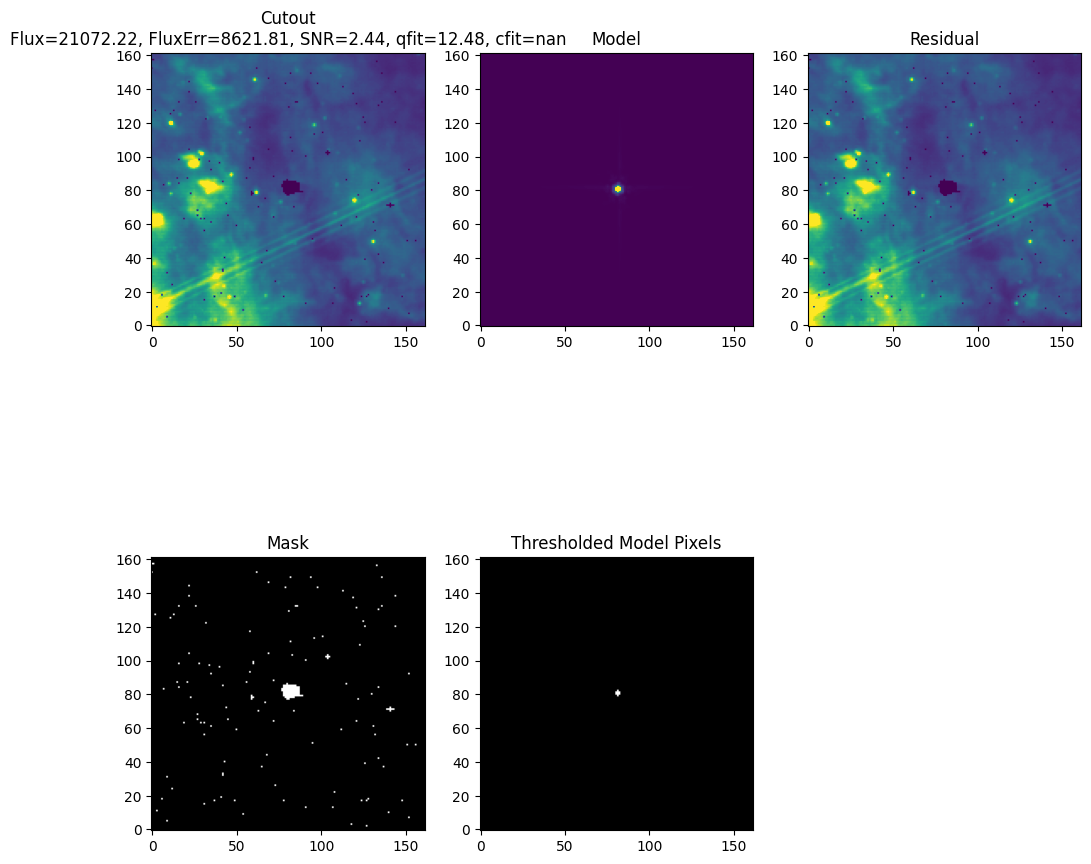

Source 9: center at (x, y) = (406, 863)
Set x_0.bounds = (77, 85)
Set y_0.bounds = (77, 85)
 id group_id group_size    local_bkg     x_init y_init     flux_init           x_fit             y_fit            flux_fit           x_err               y_err             flux_err     npixfit        qfit        cfit flags             skycoord_fit                 xcentroid         ycentroid    
                                                                                                                                                                                                                                            deg,deg                                                   
--- -------- ---------- ---------------- ------ ------ ------------------ ---------------- ----------------- ----------------- ------------------ ------------------- ----------------- ------- ------------------ ---- ----- ------------------------------------ ----------------- -----------------
  1        1          1

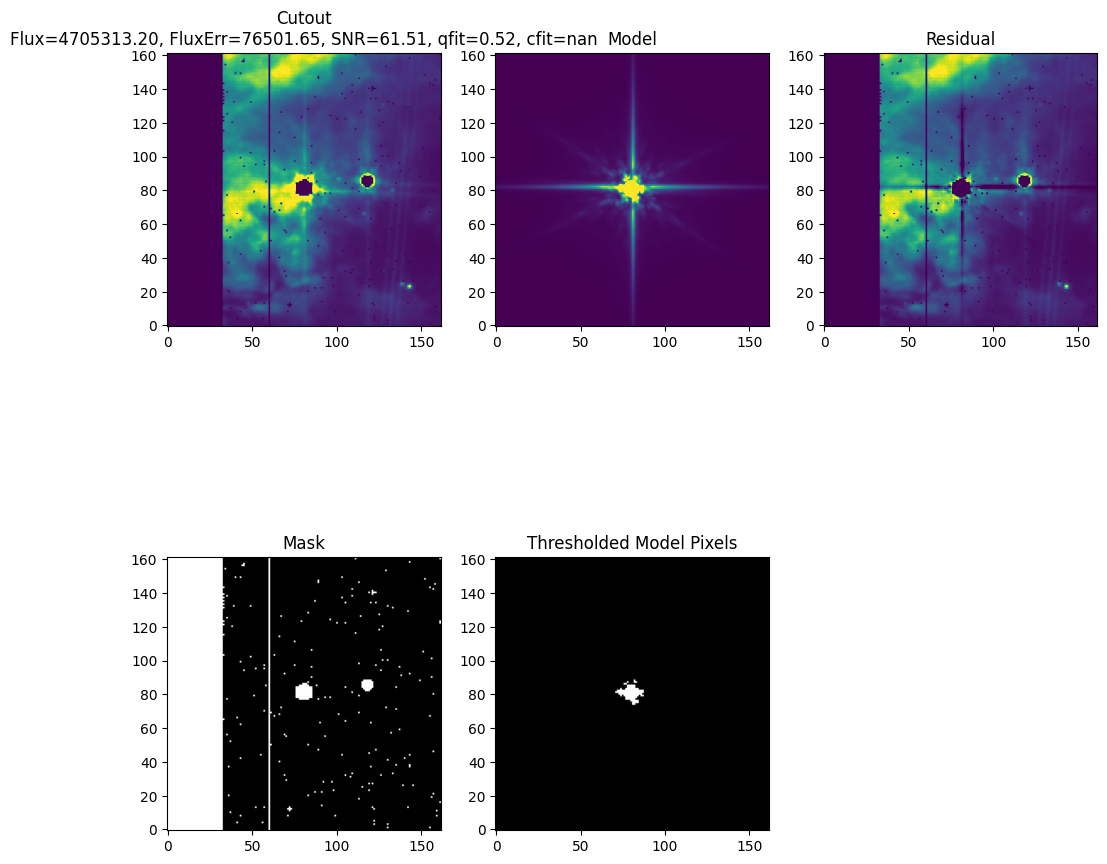

Accepting source 9 with flux=4705313.202399531, fluxerr=76501.65030813051, snr=61.5060352743718


2025-11-12 16:16:07,503 - stpipe - WARNING - MergeConflictWarning: Cannot merge meta key 'date' types <class 'str'> and <class 'str'>, choosing date='2025-11-12 16:16:06 EST'


Finished get_saturated_stars


2025-11-12 16:16:07,521 - stpipe - WARNING - Attribute `version` of type <class 'dict'> cannot be added to FITS Header - skipping
2025-11-12 16:16:07,523 - stpipe - WARNING - VerifyWarning: Keyword name 'fit_shape' is greater than 8 characters or contains characters not allowed by the FITS standard; a HIERARCH card will be created.
2025-11-12 16:16:07,524 - stpipe - WARNING - Attribute `fit_shape` of type <class 'numpy.ndarray'> cannot be added to FITS Header - skipping
2025-11-12 16:16:07,526 - stpipe - WARNING - VerifyWarning: Keyword name 'fitter_maxiters' is greater than 8 characters or contains characters not allowed by the FITS standard; a HIERARCH card will be created.
2025-11-12 16:16:07,527 - stpipe - WARNING - VerifyWarning: Keyword name 'aperture_radius' is greater than 8 characters or contains characters not allowed by the FITS standard; a HIERARCH card will be created.
2025-11-12 16:16:07,528 - stpipe - WARNING - VerifyWarning: Keyword name 'progress_bar' is greater than 8


/orange/adamginsburg/jwst/w51/F560W/pipeline/jw06151-o002_t001_miri_f560w_5_o002_crf.fits
Removing saturated stars from /orange/adamginsburg/jwst/w51/F560W/pipeline/jw06151-o002_t001_miri_f560w_5_o002_crf.fits
Setting NaN variance to 0


Set OBSGEO-B to    -3.775064 from OBSGEO-[XYZ].
Set OBSGEO-H to 1291682795.732 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
2025-11-12 16:16:07,609 - stpipe - WARNING - FITSFixedWarning: 'obsfix' made the change 'Set OBSGEO-L to   -34.647048 from OBSGEO-[XYZ].
Set OBSGEO-B to    -3.775064 from OBSGEO-[XYZ].
Set OBSGEO-H to 1291682795.732 from OBSGEO-[XYZ]'.
2025-11-12 16:16:07,614 - stpipe - WARNING - Some non-standard WCS keywords were excluded: A_ORDER, A_0_2, A_0_3, A_0_4, A_1_1, A_1_2, A_1_3, A_2_0, A_2_1, A_2_2, A_3_0, A_3_1, A_4_0, B_ORDER, B_0_2, B_0_3, B_0_4, B_1_1, B_1_2, B_1_3, B_2_0, B_2_1, B_2_2, B_3_0, B_3_1, B_4_0, AP_ORDER, AP_0_1, AP_0_2, AP_0_3, AP_0_4, AP_1_0, AP_1_1, AP_1_2, AP_1_3, AP_2_0, AP_2_1, AP_2_2, AP_3_0, AP_3_1, AP_4_0, BP_ORDER, BP_0_1, BP_0_2, BP_0_3, BP_0_4, BP_1_0, BP_1_1, BP_1_2, BP_1_3, BP_2_0, BP_2_1, BP_2_2, BP_3_0, BP_3_1, BP_4_0 Use the ``relax`` kwarg to control this.


Running get_saturated_stars


2025-11-12 16:16:07,663 - stpipe - WARNING - FITSFixedWarning: The WCS transformation has more axes (2) than the image it is associated with (0)
2025-11-12 16:16:07,667 - stpipe - INFO - Loading grid from psf_fn=/orange/adamginsburg/jwst/w51/psfs//miri_mirim_f560w_fovp512_samp2_npsf16.fits


This is not a valid WCS!!! CDELT is wrong!! how did this HAPPEN!?!?
ignoring WCS failure so check that stuff is right...
INFO: Loading grid from psf_fn=/orange/adamginsburg/jwst/w51/psfs//miri_mirim_f560w_fovp512_samp2_npsf16.fits [unknown]
Found 7 saturated sources to process
Source 1: center at (x, y) = (234, 66)
Set x_0.bounds = (78, 84)
Set y_0.bounds = (63, 69)
PSF photometry failed for source 1 at (x,y)=(234,66): Source at (81, 66) is completely masked. Remove the source from init_params or correct the input mask.
Source 2: center at (x, y) = (889, 206)
Set x_0.bounds = (80, 82)
Set y_0.bounds = (80, 82)
 id group_id group_size    local_bkg     x_init y_init     flux_init            x_fit             y_fit            flux_fit             x_err                y_err             flux_err      npixfit        qfit       cfit flags             skycoord_fit                 xcentroid         ycentroid    
                                                                                   

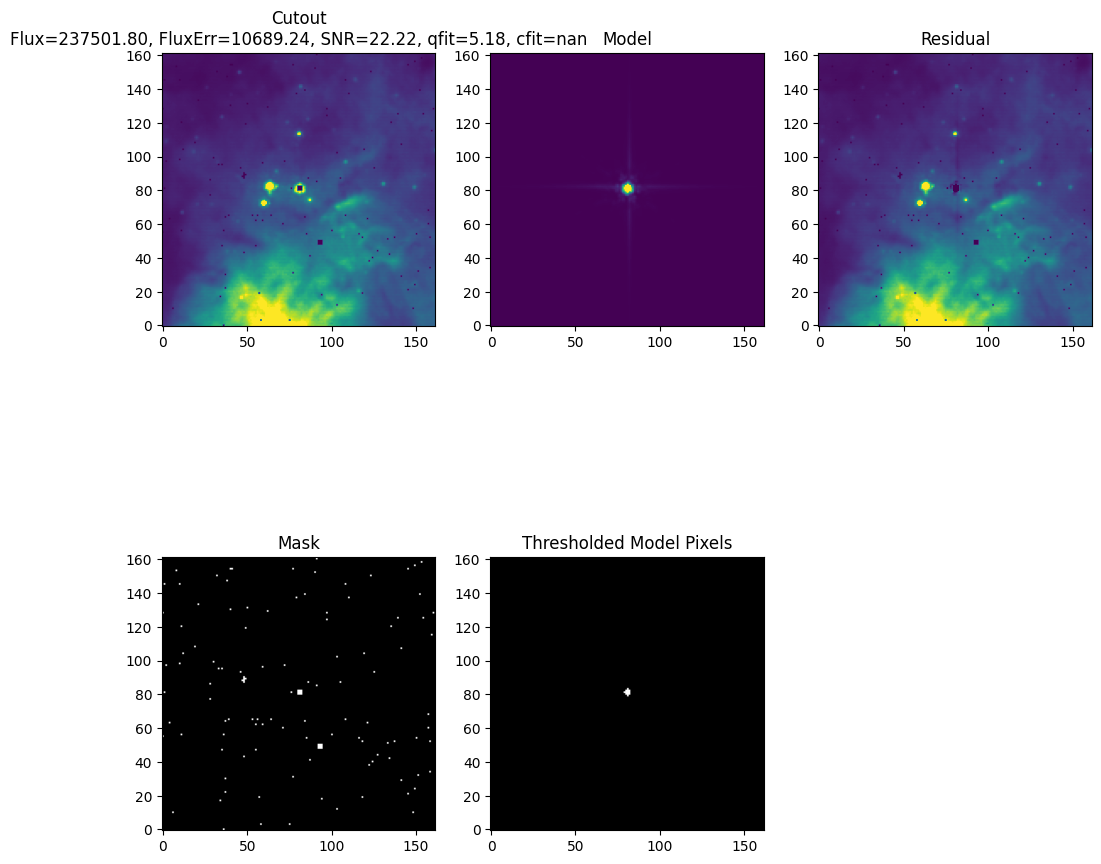

Accepting source 2 with flux=237501.80449564598, fluxerr=10689.235625005227, snr=22.21878278555861
Source 3: center at (x, y) = (958, 330)
Set x_0.bounds = (79, 83)
Set y_0.bounds = (79, 83)
 id group_id group_size     local_bkg      x_init y_init     flux_init           x_fit             y_fit           flux_fit            x_err                y_err              flux_err      npixfit        qfit        cfit flags            skycoord_fit                xcentroid         ycentroid     
                                                                                                                                                                                                                                                deg,deg                                                   
--- -------- ---------- ------------------ ------ ------ ----------------- ----------------- ----------------- ---------------- -------------------- -------------------- ------------------ ------- --------------

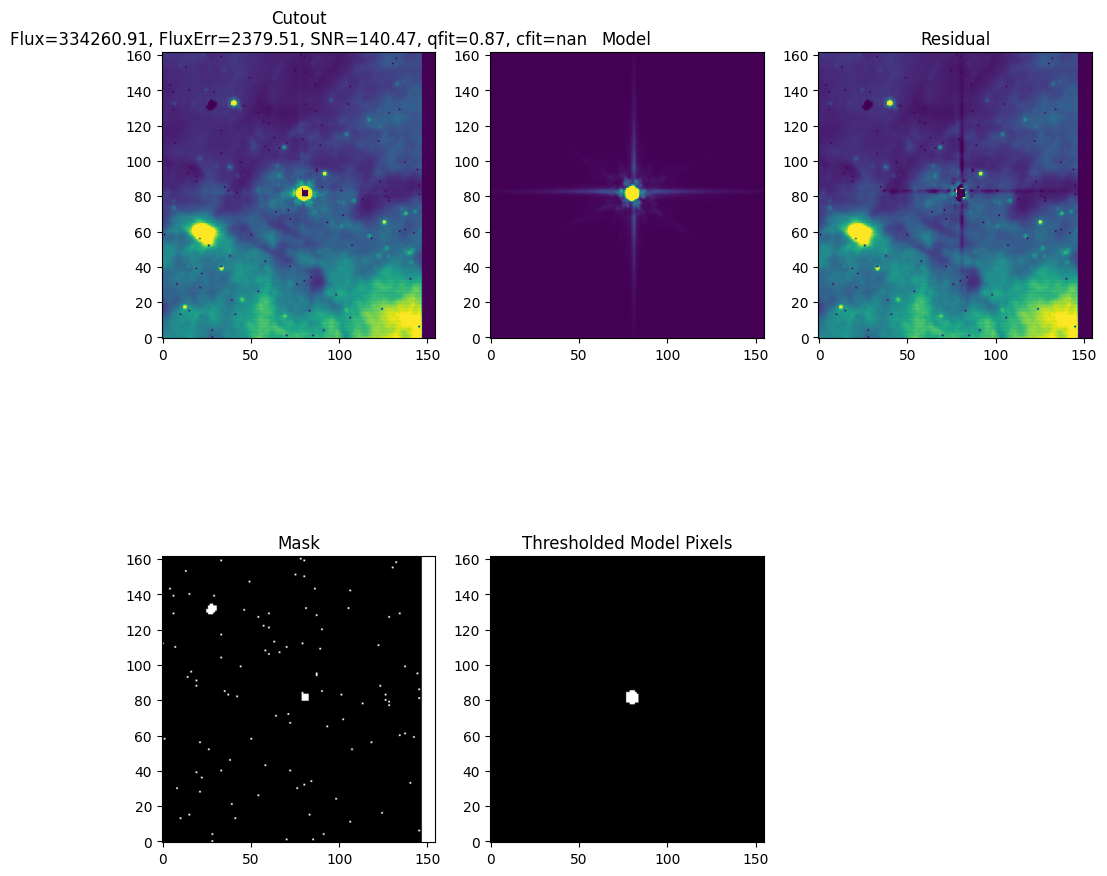

Accepting source 3 with flux=334260.910971542, fluxerr=2379.5095028089495, snr=140.47471152225097


2025-11-12 16:16:09,900 - stpipe - WARNING - MergeConflictWarning: Cannot merge meta key 'date' types <class 'str'> and <class 'str'>, choosing date='2025-11-12 16:16:09 EST'


Source 4: center at (x, y) = (742, 335)
Set x_0.bounds = (80, 82)
Set y_0.bounds = (80, 82)
 id group_id group_size     local_bkg      x_init y_init     flux_init          x_fit       y_fit      flux_fit     x_err y_err flux_err npixfit        qfit        cfit flags             skycoord_fit                xcentroid     ycentroid
                                                                                                                                                                                             deg,deg                                          
--- -------- ---------- ------------------ ------ ------ ----------------- ---------------- ----- ----------------- ----- ----- -------- ------- ------------------ ---- ----- ----------------------------------- ----------------- ---------
  1        1          1 141.82862091064453     81     81 328952.1115428937 80.0832840164765  82.0 -9435.47609429434   nan   nan      nan    6496 -23.63520108410331  nan     5 290.916330081947

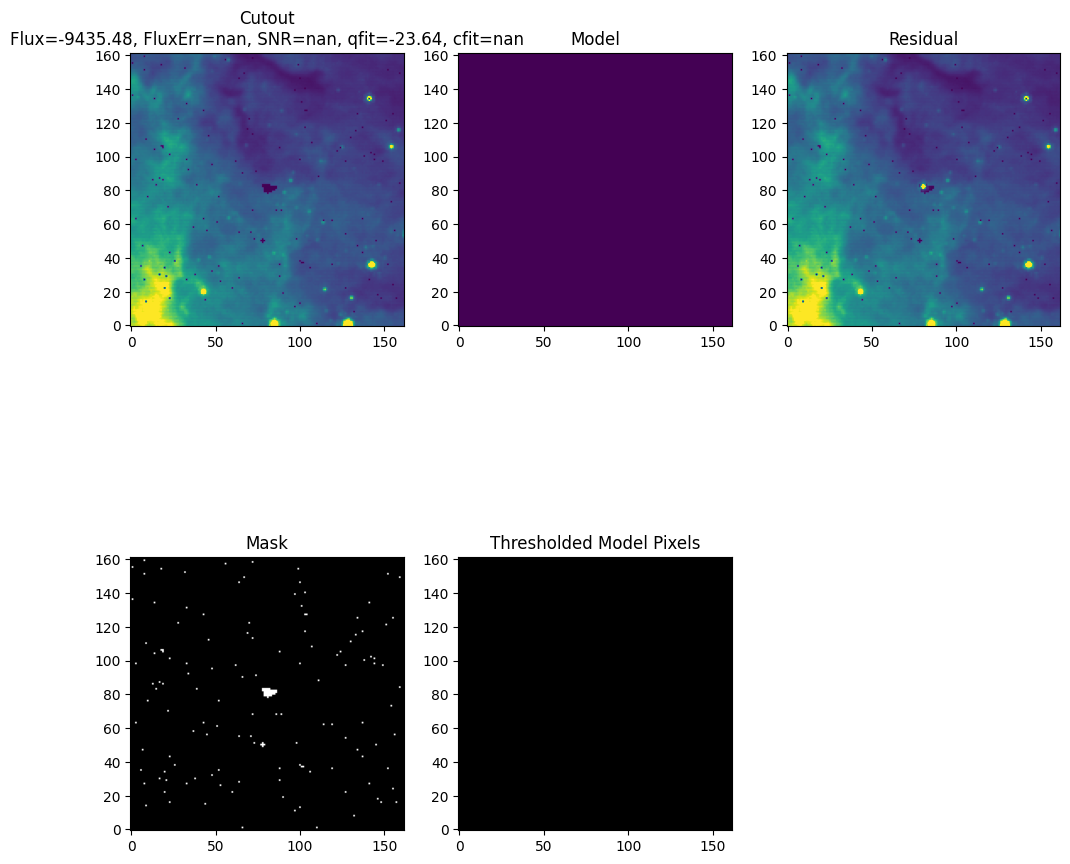

Source 5: center at (x, y) = (816, 470)
Set x_0.bounds = (80, 82)
Set y_0.bounds = (80, 82)
 id group_id group_size     local_bkg     x_init y_init     flux_init            x_fit             y_fit            flux_fit            x_err              y_err             flux_err      npixfit        qfit       cfit flags             skycoord_fit                xcentroid         ycentroid    
                                                                                                                                                                                                                                              deg,deg                                                  
--- -------- ---------- ----------------- ------ ------ ------------------ ----------------- ----------------- ------------------ ------------------ ------------------ ------------------ ------- ----------------- ---- ----- ----------------------------------- ----------------- -----------------
  1        1        

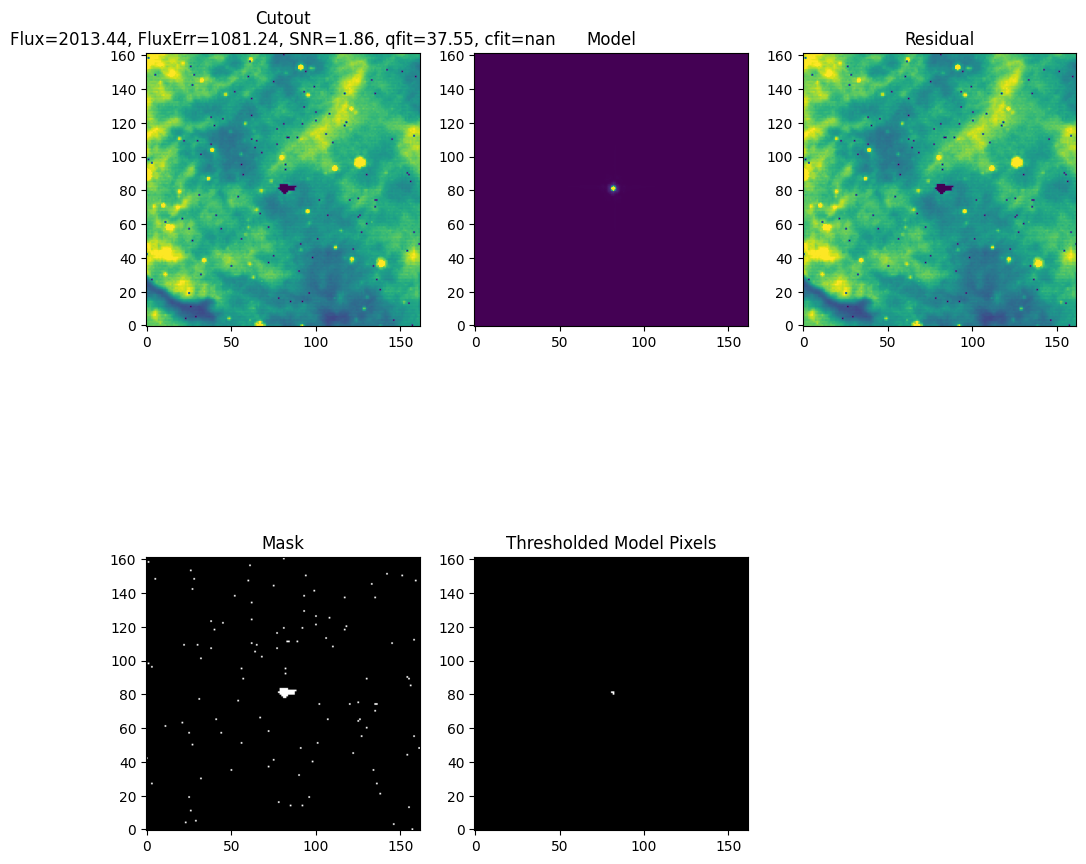

Source 6: center at (x, y) = (781, 671)
Set x_0.bounds = (78, 84)
Set y_0.bounds = (78, 84)
 id group_id group_size     local_bkg      x_init y_init     flux_init           x_fit             y_fit            flux_fit           x_err              y_err             flux_err     npixfit        qfit        cfit flags             skycoord_fit                 xcentroid         ycentroid    
                                                                                                                                                                                                                                             deg,deg                                                   
--- -------- ---------- ------------------ ------ ------ ----------------- ----------------- ----------------- ----------------- ------------------ ------------------ ----------------- ------- ------------------ ---- ----- ------------------------------------ ----------------- -----------------
  1        1        

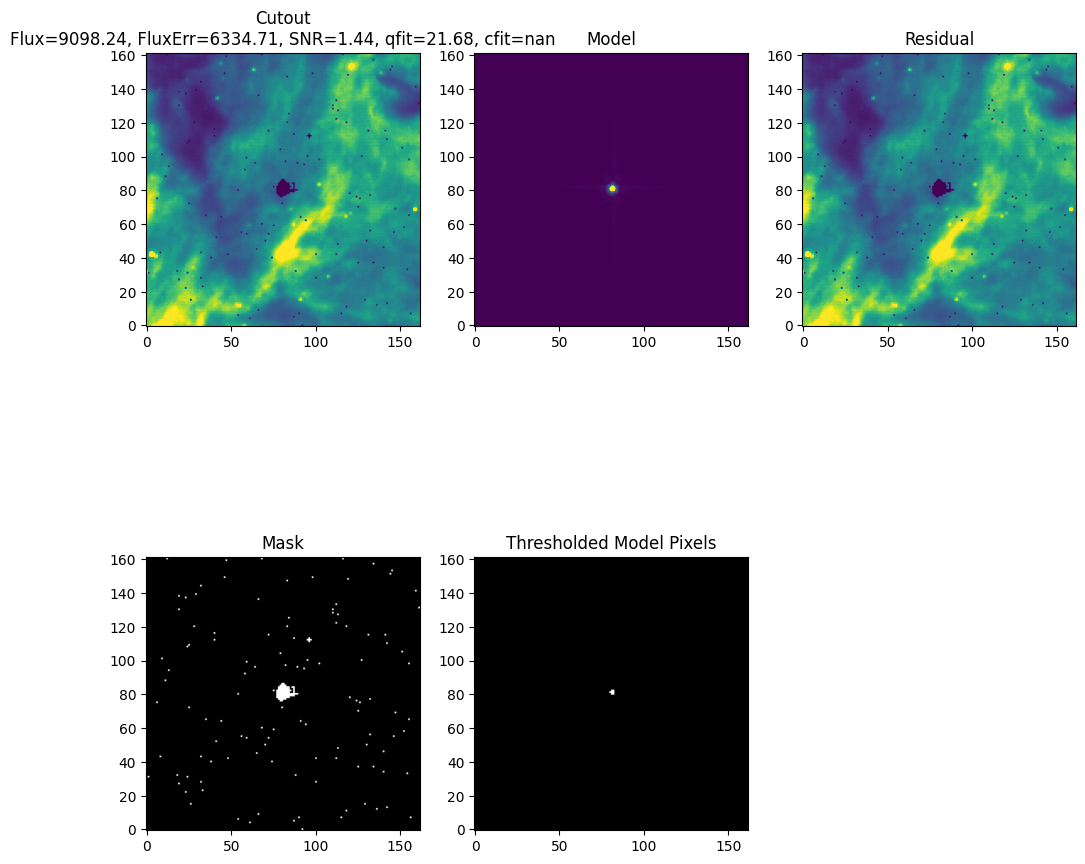

Source 7: center at (x, y) = (599, 730)
Set x_0.bounds = (78, 84)
Set y_0.bounds = (78, 84)
 id group_id group_size     local_bkg      x_init y_init    flux_init           x_fit             y_fit             flux_fit            x_err              y_err            flux_err     npixfit         qfit        cfit flags             skycoord_fit                 xcentroid         ycentroid    
                                                                                                                                                                                                                                              deg,deg                                                   
--- -------- ---------- ------------------ ------ ------ ---------------- ----------------- ----------------- ------------------- ------------------ ----------------- ----------------- ------- ------------------- ---- ----- ------------------------------------ ----------------- -----------------
  1        1     

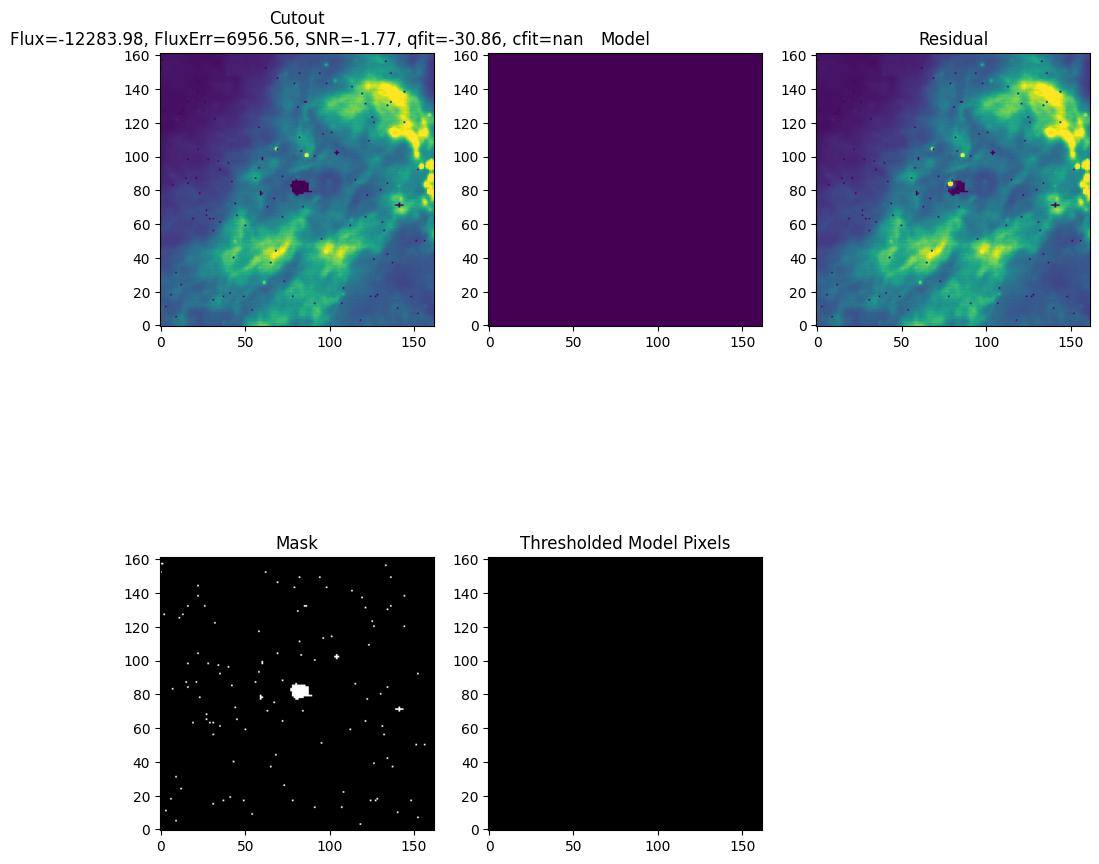

Finished get_saturated_stars


2025-11-12 16:16:14,281 - stpipe - WARNING - Attribute `version` of type <class 'dict'> cannot be added to FITS Header - skipping
2025-11-12 16:16:14,283 - stpipe - WARNING - VerifyWarning: Keyword name 'fit_shape' is greater than 8 characters or contains characters not allowed by the FITS standard; a HIERARCH card will be created.
2025-11-12 16:16:14,285 - stpipe - WARNING - Attribute `fit_shape` of type <class 'numpy.ndarray'> cannot be added to FITS Header - skipping
2025-11-12 16:16:14,287 - stpipe - WARNING - VerifyWarning: Keyword name 'fitter_maxiters' is greater than 8 characters or contains characters not allowed by the FITS standard; a HIERARCH card will be created.
2025-11-12 16:16:14,288 - stpipe - WARNING - VerifyWarning: Keyword name 'aperture_radius' is greater than 8 characters or contains characters not allowed by the FITS standard; a HIERARCH card will be created.
2025-11-12 16:16:14,290 - stpipe - WARNING - VerifyWarning: Keyword name 'progress_bar' is greater than 8


/orange/adamginsburg/jwst/w51/F560W/pipeline/jw06151-o002_t001_miri_f560w_0_o002_crf.fits
Removing saturated stars from /orange/adamginsburg/jwst/w51/F560W/pipeline/jw06151-o002_t001_miri_f560w_0_o002_crf.fits
Setting NaN variance to 0


Set OBSGEO-B to    -3.810003 from OBSGEO-[XYZ].
Set OBSGEO-H to 1291940033.618 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
2025-11-12 16:16:14,634 - stpipe - WARNING - FITSFixedWarning: 'obsfix' made the change 'Set OBSGEO-L to   -34.699734 from OBSGEO-[XYZ].
Set OBSGEO-B to    -3.810003 from OBSGEO-[XYZ].
Set OBSGEO-H to 1291940033.618 from OBSGEO-[XYZ]'.
2025-11-12 16:16:14,639 - stpipe - WARNING - Some non-standard WCS keywords were excluded: A_ORDER, A_0_2, A_0_3, A_0_4, A_1_1, A_1_2, A_1_3, A_2_0, A_2_1, A_2_2, A_3_0, A_3_1, A_4_0, B_ORDER, B_0_2, B_0_3, B_0_4, B_1_1, B_1_2, B_1_3, B_2_0, B_2_1, B_2_2, B_3_0, B_3_1, B_4_0, AP_ORDER, AP_0_1, AP_0_2, AP_0_3, AP_0_4, AP_1_0, AP_1_1, AP_1_2, AP_1_3, AP_2_0, AP_2_1, AP_2_2, AP_3_0, AP_3_1, AP_4_0, BP_ORDER, BP_0_1, BP_0_2, BP_0_3, BP_0_4, BP_1_0, BP_1_1, BP_1_2, BP_1_3, BP_2_0, BP_2_1, BP_2_2, BP_3_0, BP_3_1, BP_4_0 Use the ``relax`` kwarg to control this.


Running get_saturated_stars


2025-11-12 16:16:14,754 - stpipe - WARNING - FITSFixedWarning: The WCS transformation has more axes (2) than the image it is associated with (0)
2025-11-12 16:16:14,759 - stpipe - INFO - Loading grid from psf_fn=/orange/adamginsburg/jwst/w51/psfs//miri_mirim_f560w_fovp512_samp2_npsf16.fits


This is not a valid WCS!!! CDELT is wrong!! how did this HAPPEN!?!?
ignoring WCS failure so check that stuff is right...
INFO: Loading grid from psf_fn=/orange/adamginsburg/jwst/w51/psfs//miri_mirim_f560w_fovp512_samp2_npsf16.fits [unknown]
Found 8 saturated sources to process
Source 1: center at (x, y) = (234, 66)
Set x_0.bounds = (78, 84)
Set y_0.bounds = (63, 69)
PSF photometry failed for source 1 at (x,y)=(234,66): Source at (81, 66) is completely masked. Remove the source from init_params or correct the input mask.
Source 2: center at (x, y) = (451, 133)
Set x_0.bounds = (76, 86)
Set y_0.bounds = (76, 86)
 id group_id group_size     local_bkg      x_init y_init     flux_init            x_fit             y_fit           flux_fit            x_err               y_err             flux_err     npixfit         qfit        cfit flags              skycoord_fit                 xcentroid          ycentroid     
                                                                                

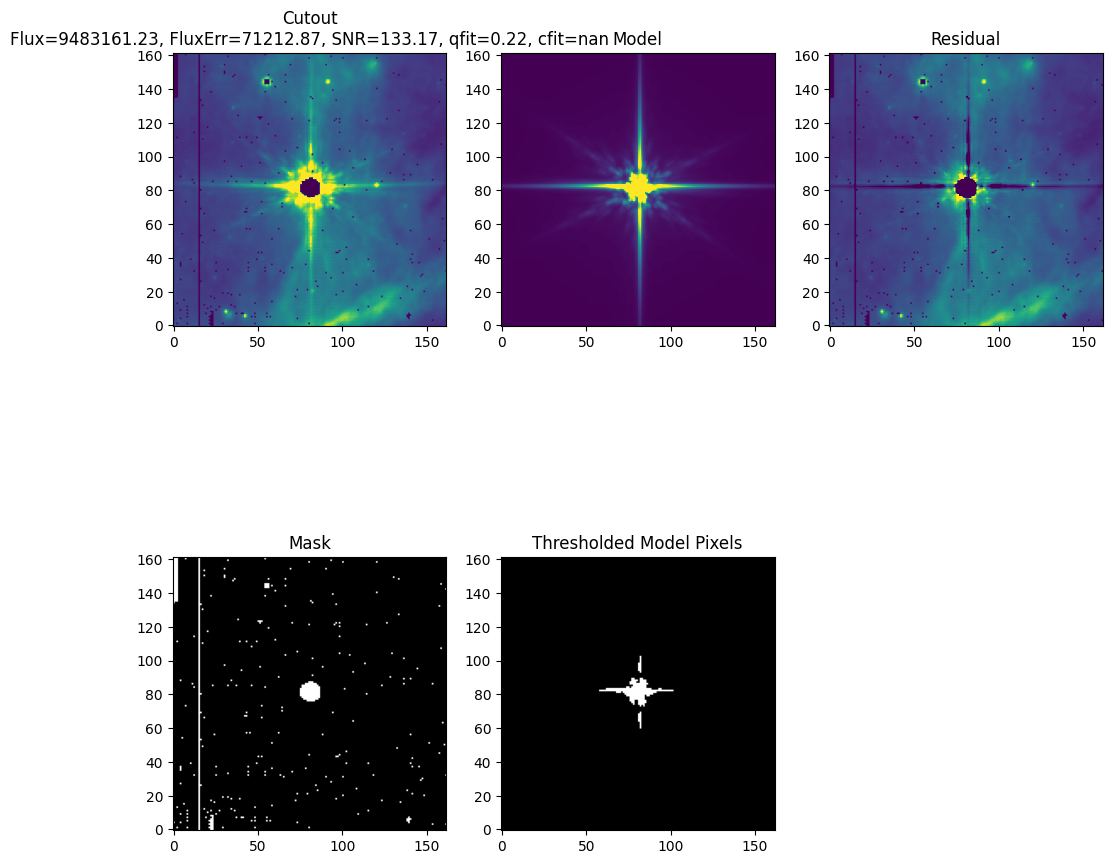

Accepting source 2 with flux=9483161.23275209, fluxerr=71212.86608881912, snr=133.16640311772267
Source 3: center at (x, y) = (425, 196)
Set x_0.bounds = (80, 82)
Set y_0.bounds = (80, 82)
 id group_id group_size     local_bkg     x_init y_init     flux_init           x_fit             y_fit            flux_fit             x_err               y_err              flux_err     npixfit        qfit        cfit flags              skycoord_fit                 xcentroid          ycentroid     
                                                                                                                                                                                                                                                 deg,deg                                                     
--- -------- ---------- ----------------- ------ ------ ------------------ ---------------- ----------------- ------------------ ------------------- -------------------- ----------------- ------- -----------

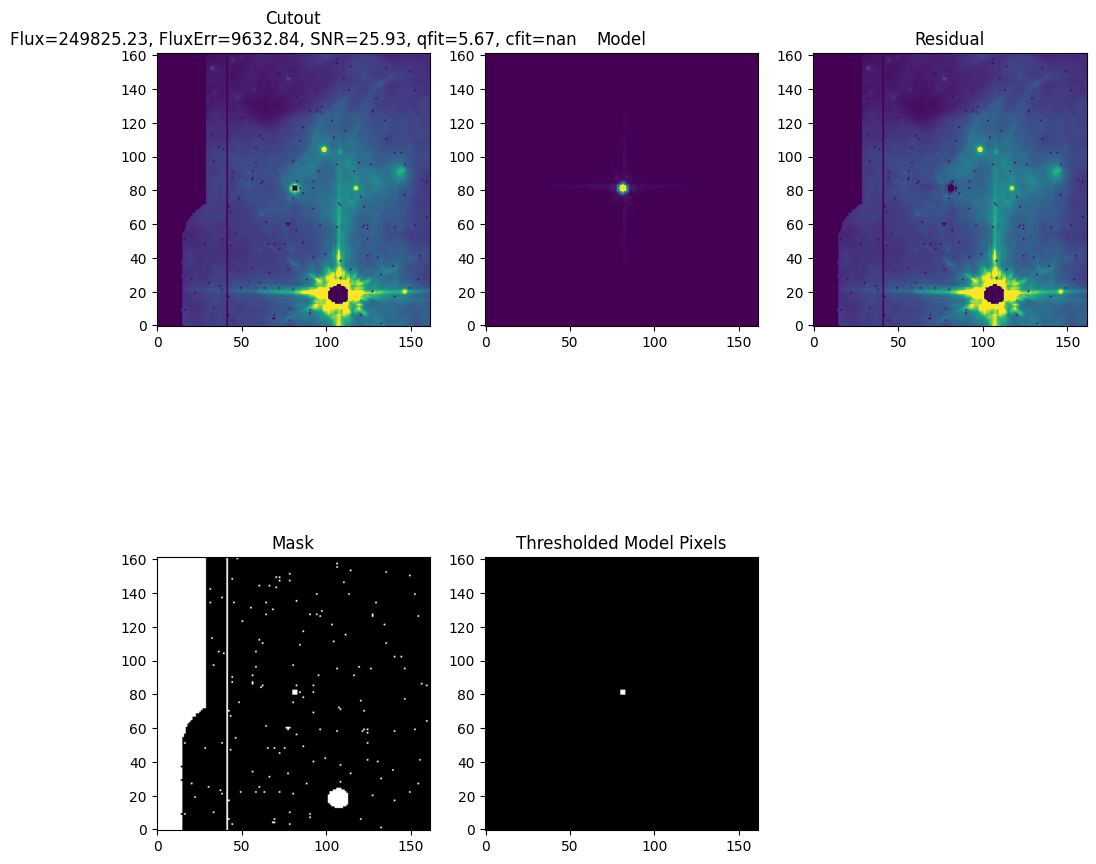

Accepting source 3 with flux=249825.22960399959, fluxerr=9632.839160094387, snr=25.93474524509259


2025-11-12 16:16:16,771 - stpipe - WARNING - MergeConflictWarning: Cannot merge meta key 'date' types <class 'str'> and <class 'str'>, choosing date='2025-11-12 16:16:16 EST'


Source 4: center at (x, y) = (742, 335)
Set x_0.bounds = (80, 82)
Set y_0.bounds = (80, 82)
 id group_id group_size     local_bkg      x_init y_init     flux_init     x_fit       y_fit            flux_fit      x_err y_err flux_err npixfit        qfit       cfit flags             skycoord_fit            xcentroid     ycentroid     
                                                                                                                                                                                              deg,deg                                           
--- -------- ---------- ------------------ ------ ------ ----------------- ----- ----------------- ------------------ ----- ----- -------- ------- ----------------- ---- ----- ----------------------------------- --------- ------------------
  1        1          1 142.82289123535156     81     81 362432.6803601091  82.0 80.34123871578224 6694.9976590815295   nan   nan      nan    6496 31.67063463004648  nan     1 290.92437

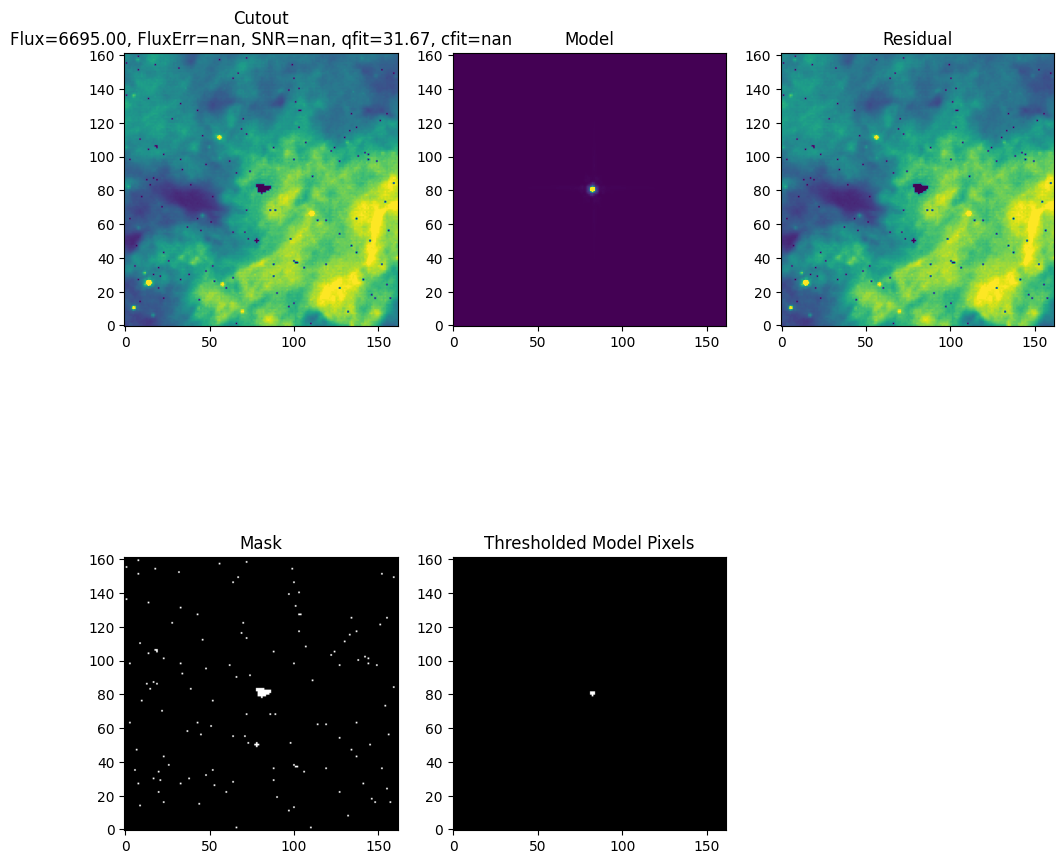

Source 5: center at (x, y) = (816, 470)
Set x_0.bounds = (80, 82)
Set y_0.bounds = (80, 82)


2025-11-12 16:16:18,788 - stpipe - WARNING - One or more fit(s) may not have converged. Please check the "flags" column in the output table.


 id group_id group_size     local_bkg     x_init y_init     flux_init      x_fit       y_fit             flux_fit      x_err y_err flux_err npixfit        qfit        cfit flags              skycoord_fit             xcentroid     ycentroid     
                                                                                                                                                                                                 deg,deg                                            
--- -------- ---------- ----------------- ------ ------ ------------------ ----- ----------------- ------------------- ----- ----- -------- ------- ------------------ ---- ----- ------------------------------------- --------- ------------------
  1        1          1 53.83015441894531     81     81 126190.17280563753  82.0 80.64676952745792 -12986.142079352592   nan   nan      nan    6487 -4.378419696600819  nan    13 290.92438618998005,14.503805157794204     817.0 469.64676952745793
-0.002431839
Number 

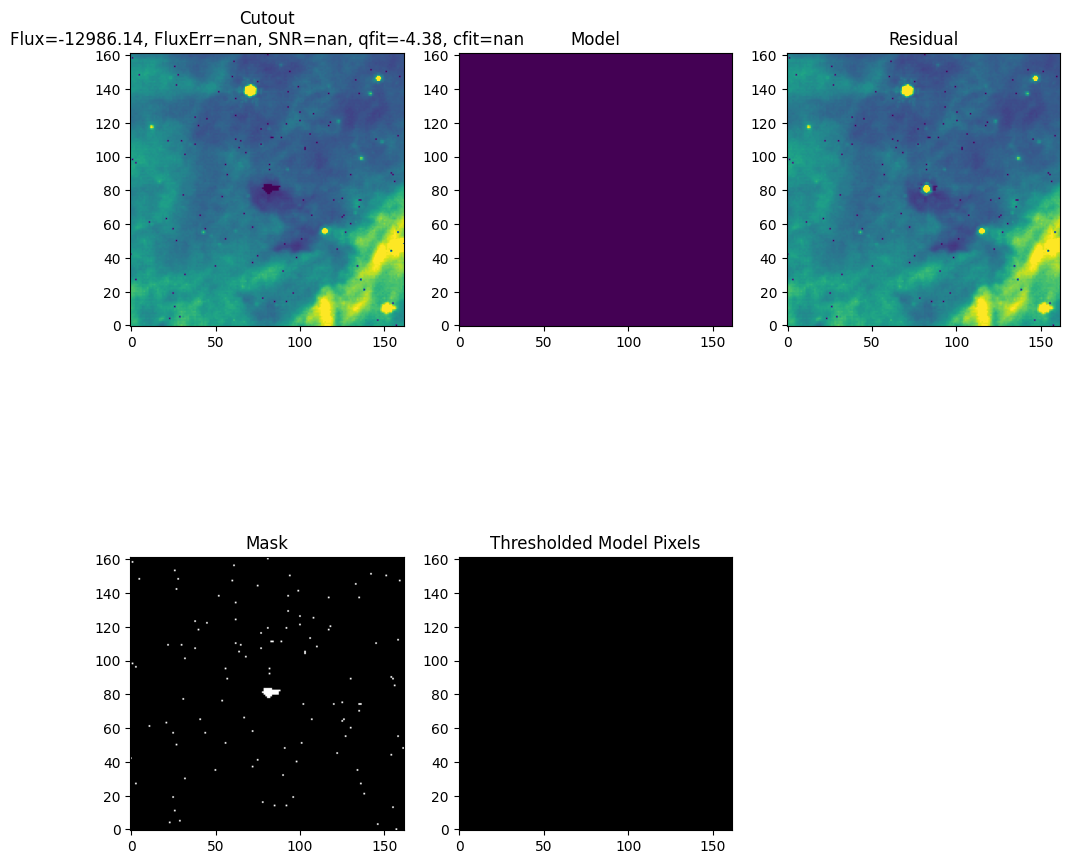

Source 6: center at (x, y) = (652, 548)
Set x_0.bounds = (78, 84)
Set y_0.bounds = (78, 84)
 id group_id group_size    local_bkg     x_init y_init     flux_init            x_fit            y_fit            flux_fit             x_err                y_err              flux_err     npixfit         qfit        cfit flags             skycoord_fit                xcentroid         ycentroid    
                                                                                                                                                                                                                                                 deg,deg                                                  
--- -------- ---------- ---------------- ------ ------ ------------------ ----------------- ---------------- ------------------ -------------------- -------------------- ----------------- ------- ------------------- ---- ----- ----------------------------------- ----------------- -----------------
  1        

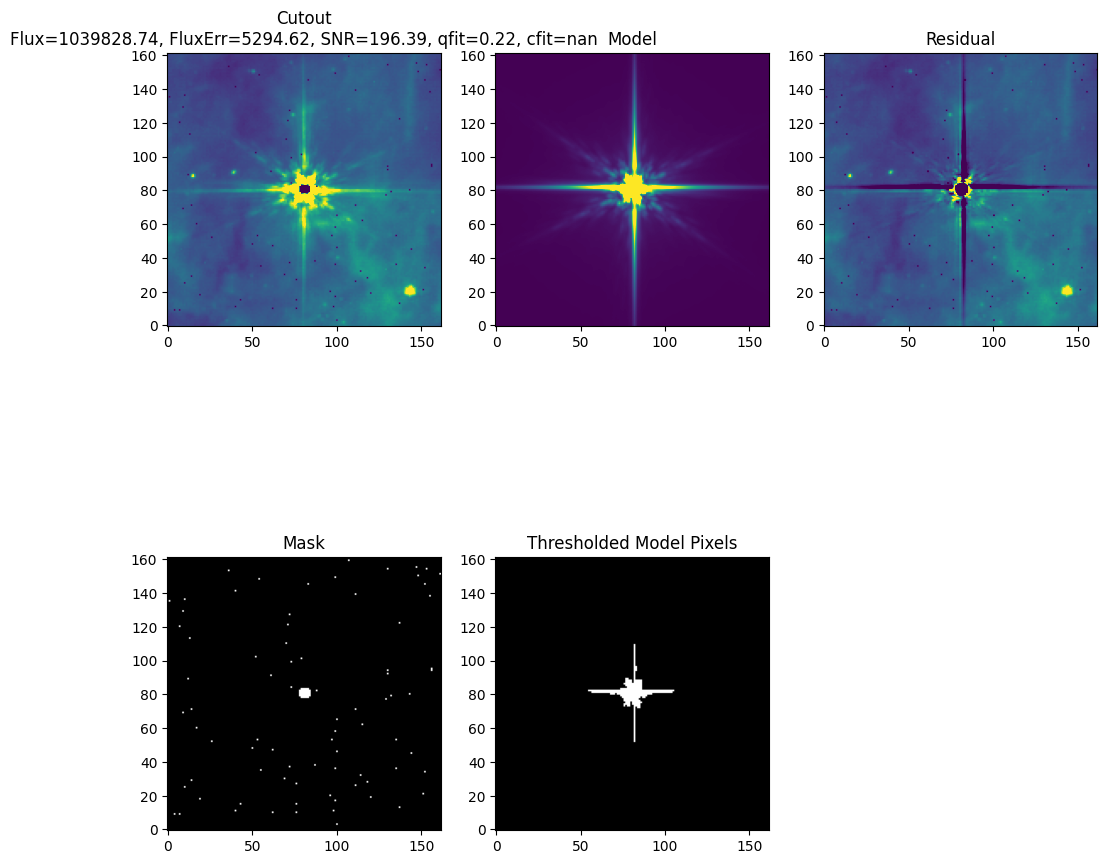

Accepting source 6 with flux=1039828.7350620832, fluxerr=5294.621019965723, snr=196.3934210099168


2025-11-12 16:16:20,495 - stpipe - WARNING - MergeConflictWarning: Cannot merge meta key 'date' types <class 'str'> and <class 'str'>, choosing date='2025-11-12 16:16:19 EST'


Source 7: center at (x, y) = (781, 671)
Set x_0.bounds = (78, 84)
Set y_0.bounds = (78, 84)
 id group_id group_size     local_bkg     x_init y_init     flux_init           x_fit       y_fit      flux_fit      x_err y_err flux_err npixfit        qfit        cfit flags              skycoord_fit                 xcentroid     ycentroid
                                                                                                                                                                                               deg,deg                                           
--- -------- ---------- ----------------- ------ ------ ----------------- ----------------- ----- ------------------ ----- ----- -------- ------- ------------------ ---- ----- ------------------------------------- ----------------- ---------
  1        1          1 38.20198059082031     81     81 96239.68671904481 79.25071209606165  84.0 15235.480222623357   nan   nan      nan    6443 2.2103319880989587  nan     1 290.92

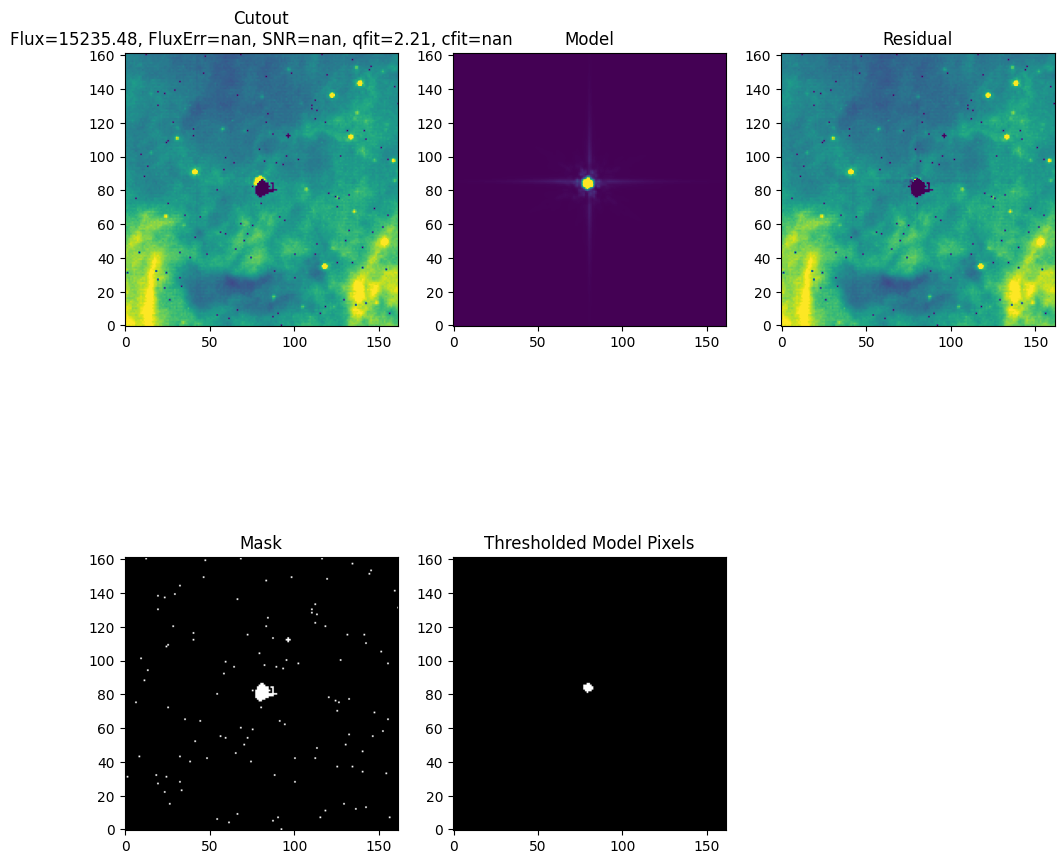

Source 8: center at (x, y) = (599, 730)
Set x_0.bounds = (78, 84)
Set y_0.bounds = (78, 84)
 id group_id group_size     local_bkg     x_init y_init     flux_init            x_fit             y_fit             flux_fit            x_err              y_err             flux_err     npixfit        qfit        cfit flags              skycoord_fit                 xcentroid         ycentroid    
                                                                                                                                                                                                                                                deg,deg                                                   
--- -------- ---------- ----------------- ------ ------ ------------------ ----------------- ----------------- ------------------- ------------------ ------------------ ----------------- ------- ------------------ ---- ----- ------------------------------------- ----------------- -----------------
  1        

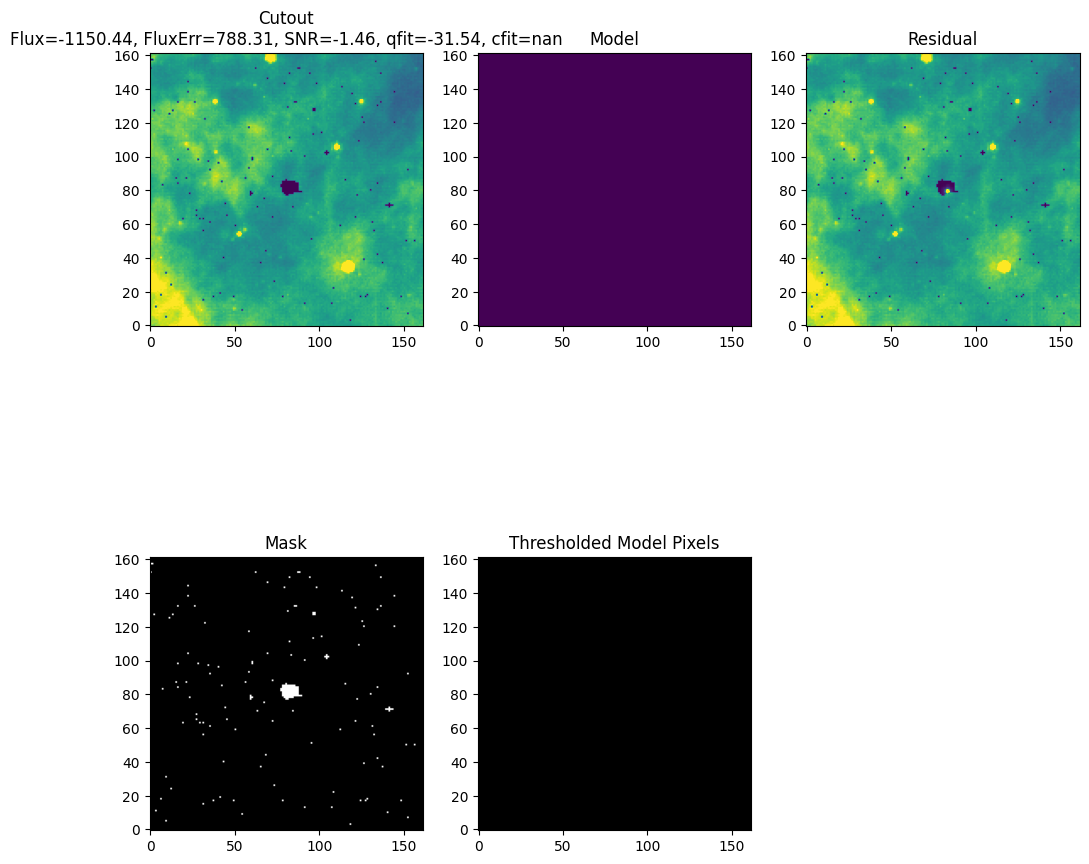

Finished get_saturated_stars


2025-11-12 16:16:23,132 - stpipe - WARNING - Attribute `version` of type <class 'dict'> cannot be added to FITS Header - skipping
2025-11-12 16:16:23,133 - stpipe - WARNING - VerifyWarning: Keyword name 'fit_shape' is greater than 8 characters or contains characters not allowed by the FITS standard; a HIERARCH card will be created.
2025-11-12 16:16:23,135 - stpipe - WARNING - Attribute `fit_shape` of type <class 'numpy.ndarray'> cannot be added to FITS Header - skipping
2025-11-12 16:16:23,136 - stpipe - WARNING - VerifyWarning: Keyword name 'fitter_maxiters' is greater than 8 characters or contains characters not allowed by the FITS standard; a HIERARCH card will be created.
2025-11-12 16:16:23,138 - stpipe - WARNING - VerifyWarning: Keyword name 'aperture_radius' is greater than 8 characters or contains characters not allowed by the FITS standard; a HIERARCH card will be created.
2025-11-12 16:16:23,139 - stpipe - WARNING - VerifyWarning: Keyword name 'progress_bar' is greater than 8


/orange/adamginsburg/jwst/w51/F560W/pipeline/jw06151-o002_t001_miri_f560w_15_o002_crf.fits
Removing saturated stars from /orange/adamginsburg/jwst/w51/F560W/pipeline/jw06151-o002_t001_miri_f560w_15_o002_crf.fits
Setting NaN variance to 0


Set OBSGEO-B to    -3.699826 from OBSGEO-[XYZ].
Set OBSGEO-H to 1291130713.572 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
2025-11-12 16:16:23,263 - stpipe - WARNING - FITSFixedWarning: 'obsfix' made the change 'Set OBSGEO-L to   -34.533544 from OBSGEO-[XYZ].
Set OBSGEO-B to    -3.699826 from OBSGEO-[XYZ].
Set OBSGEO-H to 1291130713.572 from OBSGEO-[XYZ]'.
2025-11-12 16:16:23,268 - stpipe - WARNING - Some non-standard WCS keywords were excluded: A_ORDER, A_0_2, A_0_3, A_0_4, A_1_1, A_1_2, A_1_3, A_2_0, A_2_1, A_2_2, A_3_0, A_3_1, A_4_0, B_ORDER, B_0_2, B_0_3, B_0_4, B_1_1, B_1_2, B_1_3, B_2_0, B_2_1, B_2_2, B_3_0, B_3_1, B_4_0, AP_ORDER, AP_0_1, AP_0_2, AP_0_3, AP_0_4, AP_1_0, AP_1_1, AP_1_2, AP_1_3, AP_2_0, AP_2_1, AP_2_2, AP_3_0, AP_3_1, AP_4_0, BP_ORDER, BP_0_1, BP_0_2, BP_0_3, BP_0_4, BP_1_0, BP_1_1, BP_1_2, BP_1_3, BP_2_0, BP_2_1, BP_2_2, BP_3_0, BP_3_1, BP_4_0 Use the ``relax`` kwarg to control this.


Running get_saturated_stars


2025-11-12 16:16:23,318 - stpipe - WARNING - FITSFixedWarning: The WCS transformation has more axes (2) than the image it is associated with (0)
2025-11-12 16:16:23,323 - stpipe - INFO - Loading grid from psf_fn=/orange/adamginsburg/jwst/w51/psfs//miri_mirim_f560w_fovp512_samp2_npsf16.fits


This is not a valid WCS!!! CDELT is wrong!! how did this HAPPEN!?!?
ignoring WCS failure so check that stuff is right...
INFO: Loading grid from psf_fn=/orange/adamginsburg/jwst/w51/psfs//miri_mirim_f560w_fovp512_samp2_npsf16.fits [unknown]
Found 8 saturated sources to process
Source 1: center at (x, y) = (234, 66)
Set x_0.bounds = (78, 84)
Set y_0.bounds = (63, 69)
PSF photometry failed for source 1 at (x,y)=(234,66): Source at (81, 66) is completely masked. Remove the source from init_params or correct the input mask.
Source 2: center at (x, y) = (742, 335)
Set x_0.bounds = (80, 82)
Set y_0.bounds = (80, 82)
 id group_id group_size     local_bkg     x_init y_init     flux_init          x_fit             y_fit            flux_fit             x_err               y_err             flux_err      npixfit        qfit       cfit flags              skycoord_fit                 xcentroid         ycentroid    
                                                                                    

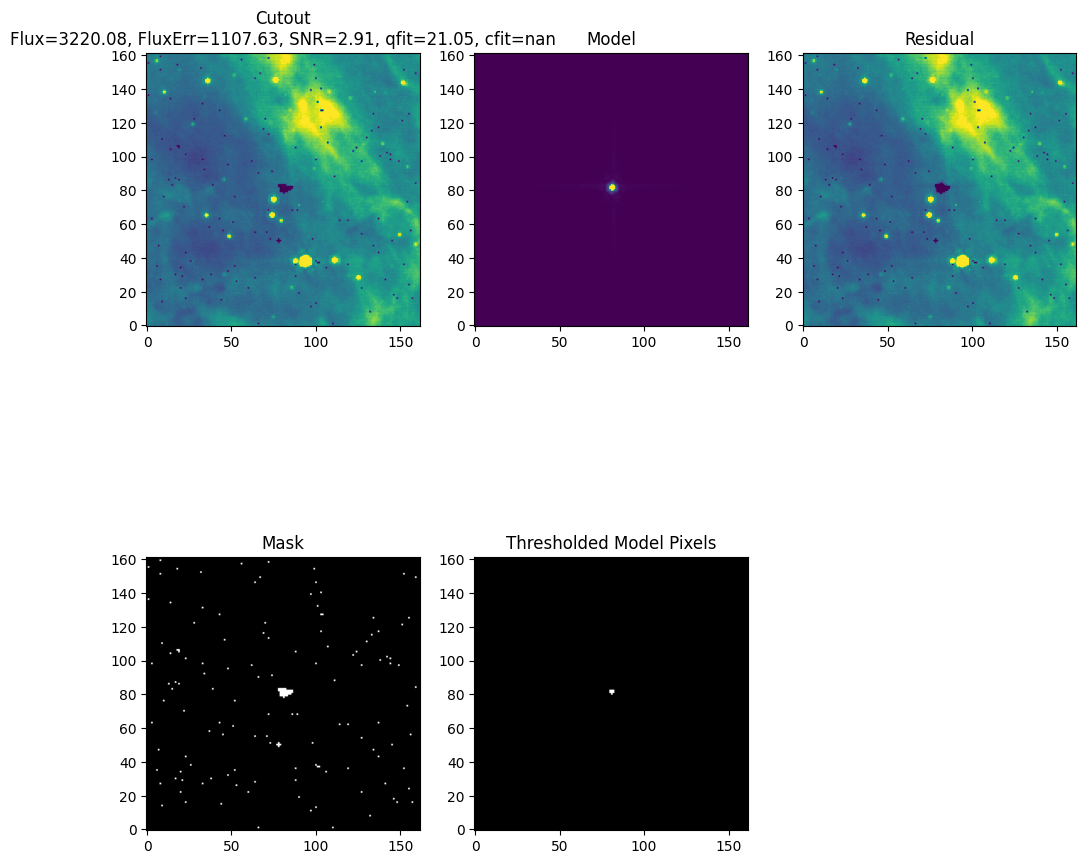

Source 3: center at (x, y) = (474, 415)
Set x_0.bounds = (79, 83)
Set y_0.bounds = (79, 83)
 id group_id group_size     local_bkg     x_init y_init     flux_init            x_fit             y_fit            flux_fit             x_err                y_err              flux_err      npixfit         qfit        cfit flags            skycoord_fit                xcentroid         ycentroid     
                                                                                                                                                                                                                                                   deg,deg                                                   
--- -------- ---------- ----------------- ------ ------ ------------------ ----------------- ----------------- ------------------ -------------------- -------------------- ------------------ ------- ------------------- ---- ----- ---------------------------------- ----------------- ------------------
  

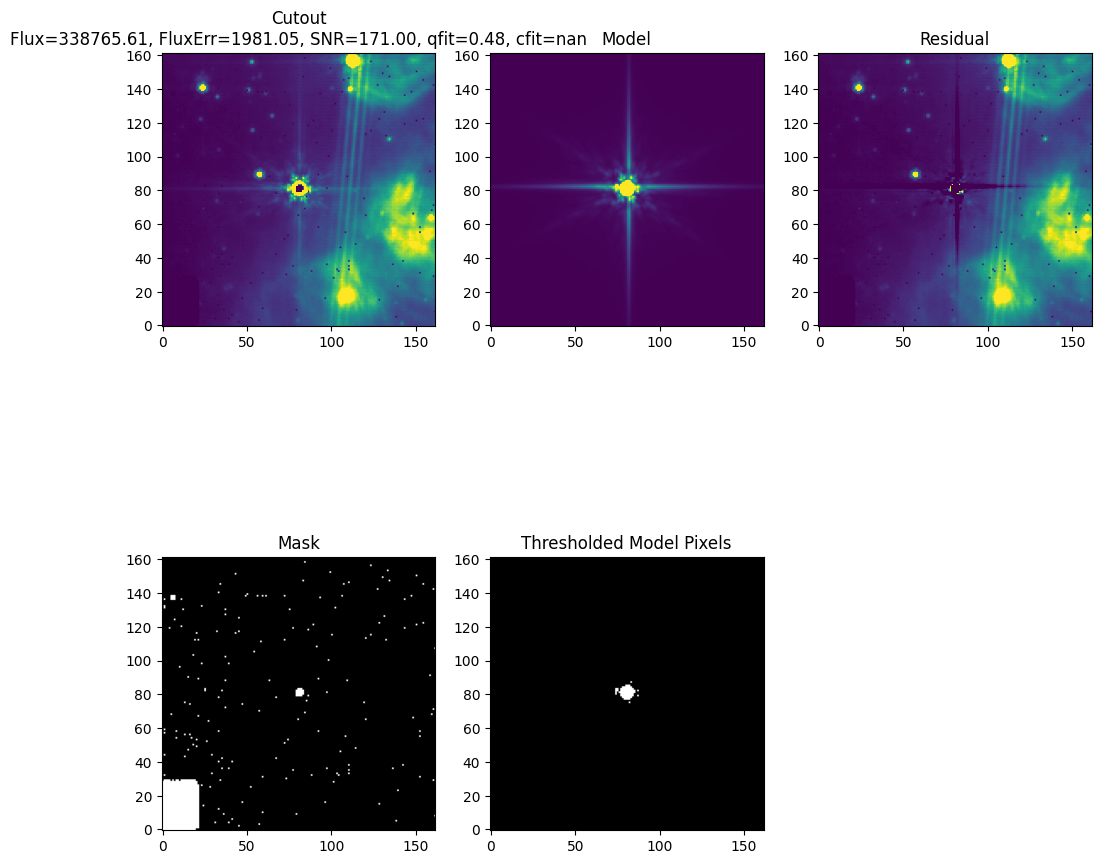

Accepting source 3 with flux=338765.60806444765, fluxerr=1981.0500846360344, snr=171.00305070110676
Source 4: center at (x, y) = (816, 470)
Set x_0.bounds = (80, 82)
Set y_0.bounds = (80, 82)
 id group_id group_size     local_bkg     x_init y_init     flux_init     x_fit y_fit      flux_fit      x_err y_err flux_err npixfit        qfit        cfit flags             skycoord_fit             xcentroid ycentroid
                                                                                                                                                                                  deg,deg                                   
--- -------- ---------- ----------------- ------ ------ ----------------- ----- ----- ------------------ ----- ----- -------- ------- ------------------ ---- ----- ------------------------------------ --------- ---------
  1        1          1 53.66974639892578     81     81 134639.1750695028  80.0  82.0 1115.0778455467691   nan   nan      nan    6489 48.26632742

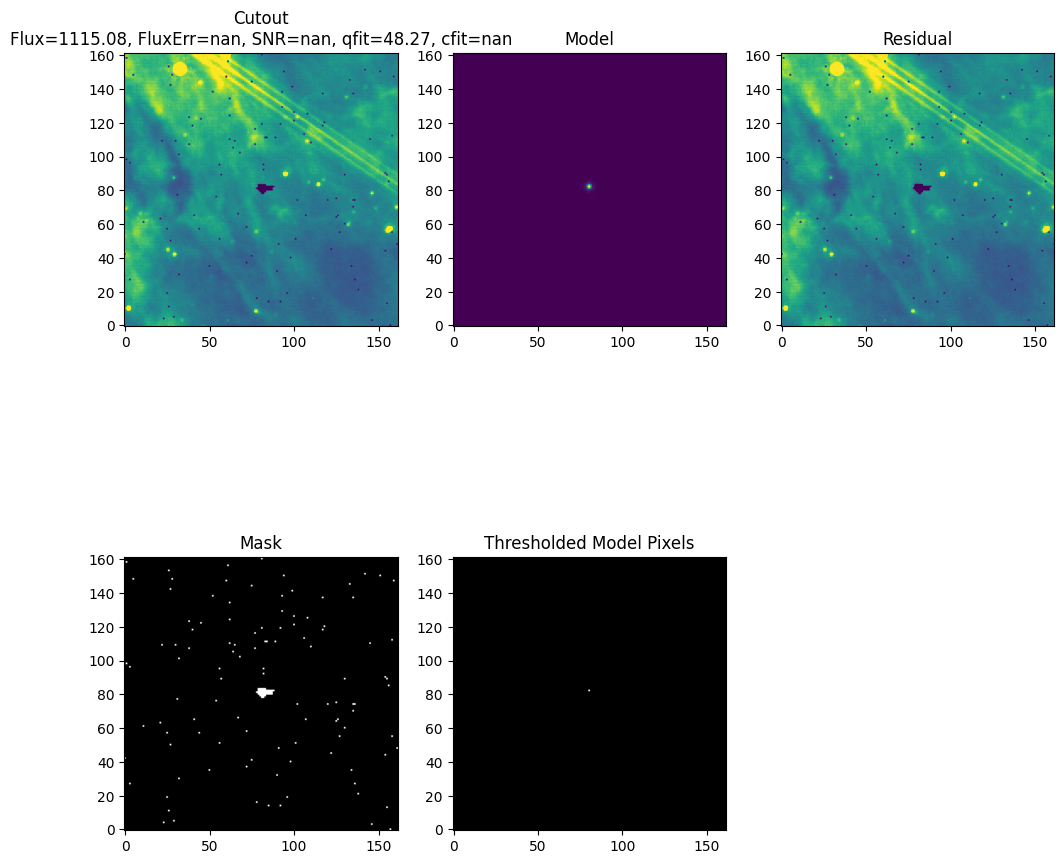

Source 5: center at (x, y) = (536, 708)
Set x_0.bounds = (57, 105)
Set y_0.bounds = (57, 105)


2025-11-12 16:16:28,452 - stpipe - WARNING - One or more fit(s) may not have converged. Please check the "flags" column in the output table.


 id group_id group_size   local_bkg    x_init y_init     flux_init           x_fit             y_fit            flux_fit      x_err y_err flux_err npixfit        qfit       cfit flags             skycoord_fit                 xcentroid         ycentroid    
                                                                                                                                                                                                      deg,deg                                                   
--- -------- ---------- -------------- ------ ------ ----------------- ----------------- ----------------- ------------------ ----- ----- -------- ------- ----------------- ---- ----- ------------------------------------ ----------------- -----------------
  1        1          1 6016.166015625     81     81 5068947.451082844 76.11347565653507 75.87507495389893 -5633449.348886487   nan   nan      nan    4151 -1.59704944014742  nan    13 290.8928498534081,14.511951057263346 531.1134

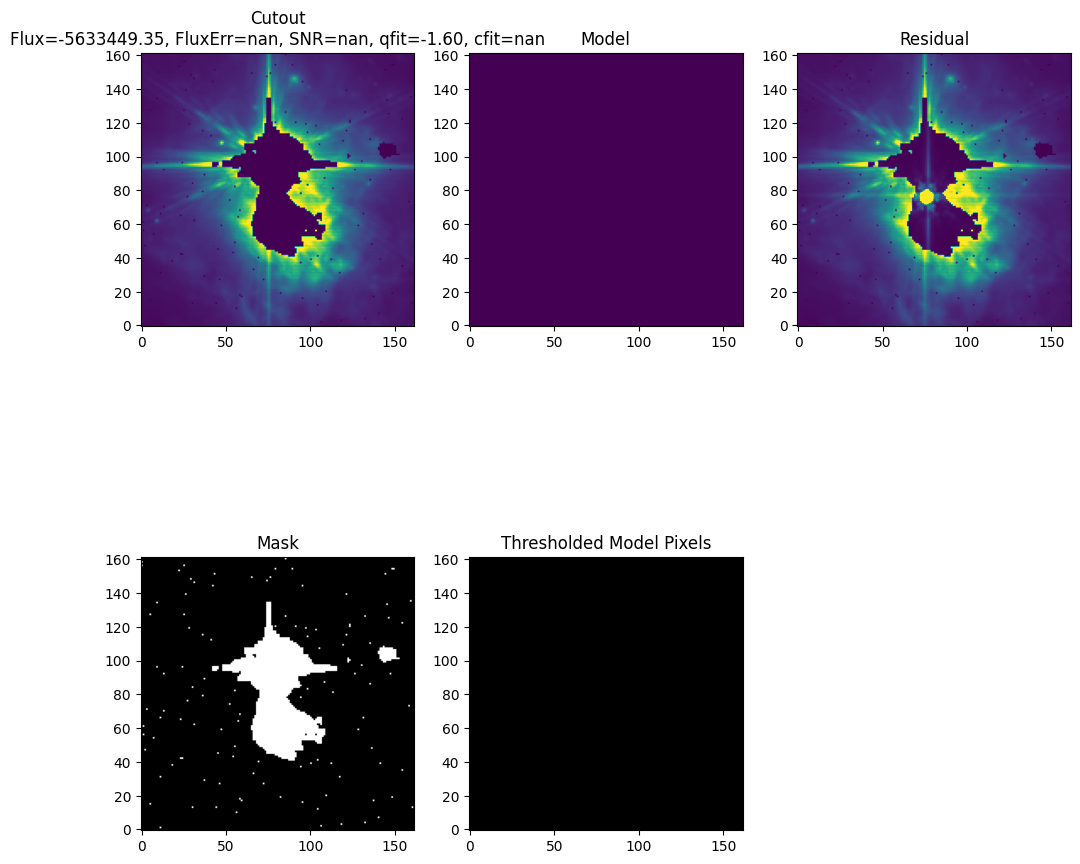

Source 6: center at (x, y) = (781, 671)
Set x_0.bounds = (78, 84)
Set y_0.bounds = (78, 84)
 id group_id group_size     local_bkg     x_init y_init     flux_init            x_fit             y_fit             flux_fit            x_err              y_err             flux_err     npixfit        qfit        cfit flags             skycoord_fit                 xcentroid         ycentroid    
                                                                                                                                                                                                                                               deg,deg                                                   
--- -------- ---------- ----------------- ------ ------ ------------------ ----------------- ----------------- ------------------- ------------------ ------------------ ----------------- ------- ------------------ ---- ----- ------------------------------------ ----------------- -----------------
  1        1  

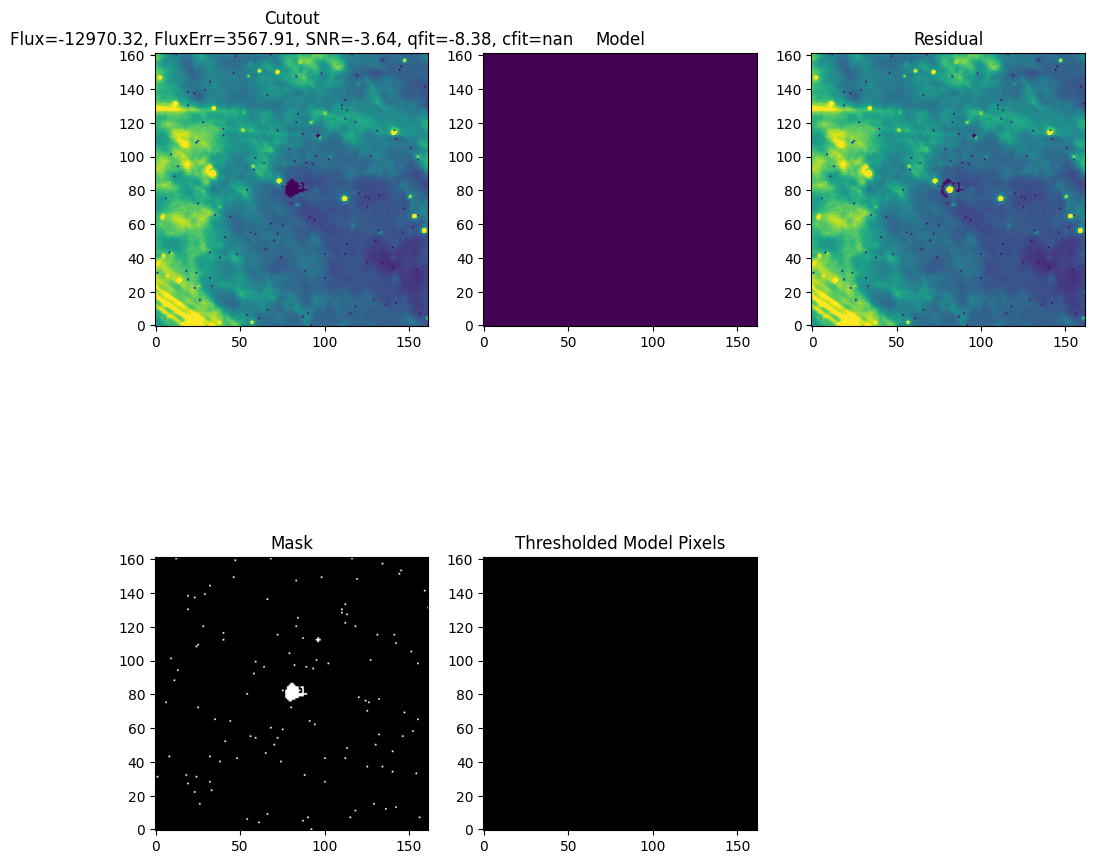

Source 7: center at (x, y) = (599, 731)
Set x_0.bounds = (78, 84)
Set y_0.bounds = (78, 84)
 id group_id group_size     local_bkg     x_init y_init    flux_init          x_fit             y_fit            flux_fit             x_err               y_err             flux_err     npixfit        qfit        cfit flags             skycoord_fit                 xcentroid         ycentroid    
                                                                                                                                                                                                                                             deg,deg                                                   
--- -------- ---------- ----------------- ------ ------ ---------------- ---------------- ----------------- ------------------ ------------------- ------------------- ----------------- ------- ------------------ ---- ----- ------------------------------------ ----------------- -----------------
  1        1        

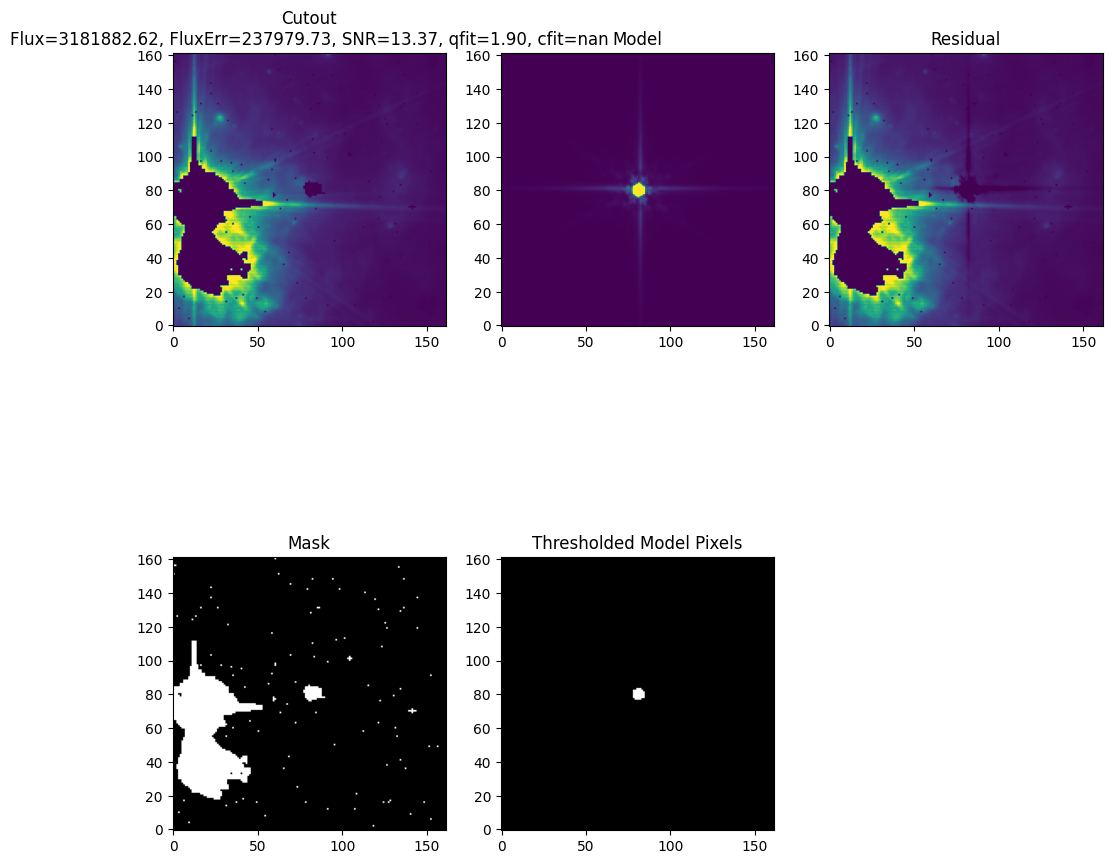

Source 8: center at (x, y) = (493, 963)
Set x_0.bounds = (77, 85)
Set y_0.bounds = (77, 85)


2025-11-12 16:16:32,062 - stpipe - WARNING - One or more fit(s) may not have converged. Please check the "flags" column in the output table.


 id group_id group_size    local_bkg     x_init y_init     flux_init           x_fit            y_fit            flux_fit     x_err y_err flux_err npixfit        qfit        cfit flags              skycoord_fit                 xcentroid          ycentroid    
                                                                                                                                                                                                        deg,deg                                                    
--- -------- ---------- ---------------- ------ ------ ----------------- ----------------- ---------------- ----------------- ----- ----- -------- ------- ------------------ ---- ----- ------------------------------------- ------------------ -----------------
  1        1          1 811.616455078125     81     81 2853380.967689881 80.59919216360065 80.5152065249292 4508409.466303459   nan   nan      nan    6390 0.5840515049240441  nan     9 290.89303714474414,14.5120319635980

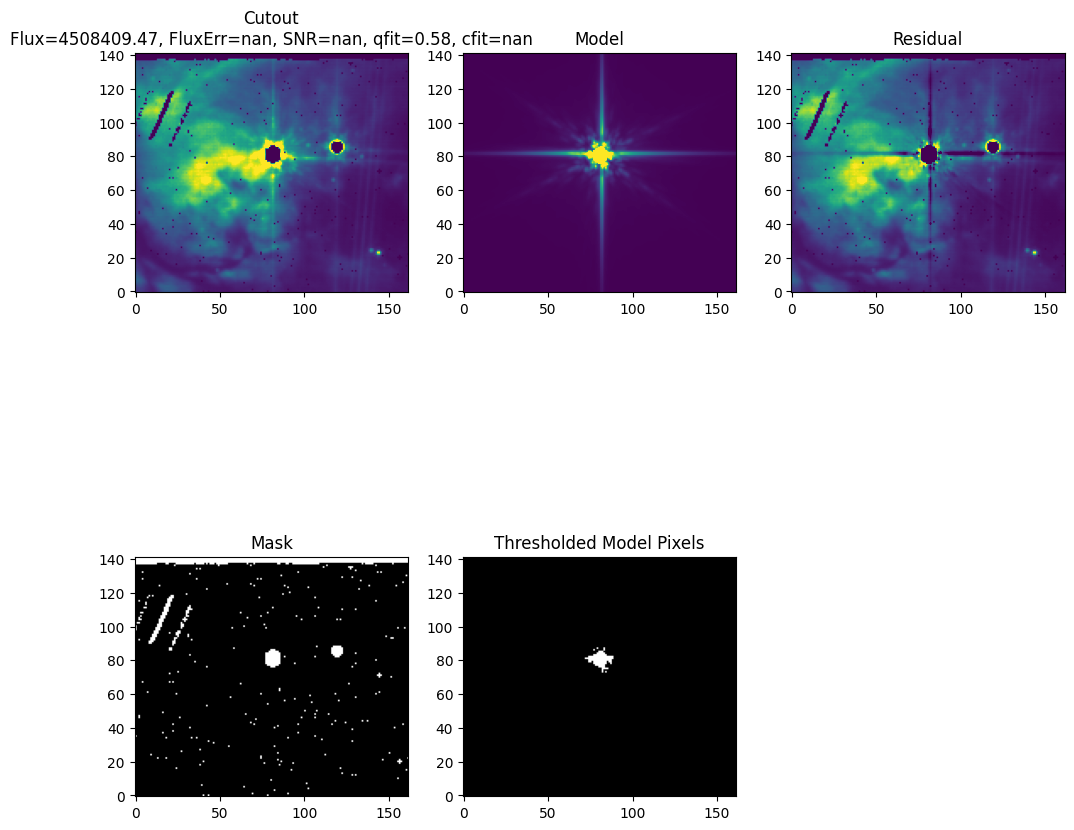

Skipping source 8 due to non-finite flux error or low SNR
  fluxerr=nan, snr=nan
Finished get_saturated_stars


2025-11-12 16:16:32,873 - stpipe - WARNING - Attribute `version` of type <class 'dict'> cannot be added to FITS Header - skipping
2025-11-12 16:16:32,875 - stpipe - WARNING - VerifyWarning: Keyword name 'fit_shape' is greater than 8 characters or contains characters not allowed by the FITS standard; a HIERARCH card will be created.
2025-11-12 16:16:32,877 - stpipe - WARNING - Attribute `fit_shape` of type <class 'numpy.ndarray'> cannot be added to FITS Header - skipping
2025-11-12 16:16:32,879 - stpipe - WARNING - VerifyWarning: Keyword name 'fitter_maxiters' is greater than 8 characters or contains characters not allowed by the FITS standard; a HIERARCH card will be created.
2025-11-12 16:16:32,880 - stpipe - WARNING - VerifyWarning: Keyword name 'aperture_radius' is greater than 8 characters or contains characters not allowed by the FITS standard; a HIERARCH card will be created.
2025-11-12 16:16:32,882 - stpipe - WARNING - VerifyWarning: Keyword name 'progress_bar' is greater than 8


/orange/adamginsburg/jwst/w51/F560W/pipeline/jw06151-o002_t001_miri_f560w_10_o002_crf.fits
Removing saturated stars from /orange/adamginsburg/jwst/w51/F560W/pipeline/jw06151-o002_t001_miri_f560w_10_o002_crf.fits
Setting NaN variance to 0


Set OBSGEO-B to    -3.735086 from OBSGEO-[XYZ].
Set OBSGEO-H to 1291389129.073 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
2025-11-12 16:16:33,086 - stpipe - WARNING - FITSFixedWarning: 'obsfix' made the change 'Set OBSGEO-L to   -34.586745 from OBSGEO-[XYZ].
Set OBSGEO-B to    -3.735086 from OBSGEO-[XYZ].
Set OBSGEO-H to 1291389129.073 from OBSGEO-[XYZ]'.
2025-11-12 16:16:33,091 - stpipe - WARNING - Some non-standard WCS keywords were excluded: A_ORDER, A_0_2, A_0_3, A_0_4, A_1_1, A_1_2, A_1_3, A_2_0, A_2_1, A_2_2, A_3_0, A_3_1, A_4_0, B_ORDER, B_0_2, B_0_3, B_0_4, B_1_1, B_1_2, B_1_3, B_2_0, B_2_1, B_2_2, B_3_0, B_3_1, B_4_0, AP_ORDER, AP_0_1, AP_0_2, AP_0_3, AP_0_4, AP_1_0, AP_1_1, AP_1_2, AP_1_3, AP_2_0, AP_2_1, AP_2_2, AP_3_0, AP_3_1, AP_4_0, BP_ORDER, BP_0_1, BP_0_2, BP_0_3, BP_0_4, BP_1_0, BP_1_1, BP_1_2, BP_1_3, BP_2_0, BP_2_1, BP_2_2, BP_3_0, BP_3_1, BP_4_0 Use the ``relax`` kwarg to control this.


Running get_saturated_stars


2025-11-12 16:16:33,207 - stpipe - WARNING - FITSFixedWarning: The WCS transformation has more axes (2) than the image it is associated with (0)
2025-11-12 16:16:33,212 - stpipe - INFO - Loading grid from psf_fn=/orange/adamginsburg/jwst/w51/psfs//miri_mirim_f560w_fovp512_samp2_npsf16.fits


This is not a valid WCS!!! CDELT is wrong!! how did this HAPPEN!?!?
ignoring WCS failure so check that stuff is right...
INFO: Loading grid from psf_fn=/orange/adamginsburg/jwst/w51/psfs//miri_mirim_f560w_fovp512_samp2_npsf16.fits [unknown]
Found 7 saturated sources to process
Source 1: center at (x, y) = (234, 66)
Set x_0.bounds = (78, 84)
Set y_0.bounds = (63, 69)
PSF photometry failed for source 1 at (x,y)=(234,66): Source at (81, 66) is completely masked. Remove the source from init_params or correct the input mask.
Source 2: center at (x, y) = (506, 141)
Set x_0.bounds = (79, 83)
Set y_0.bounds = (79, 83)
 id group_id group_size    local_bkg     x_init y_init     flux_init            x_fit             y_fit            flux_fit            x_err                y_err              flux_err      npixfit        qfit        cfit flags              skycoord_fit                 xcentroid         ycentroid     
                                                                                

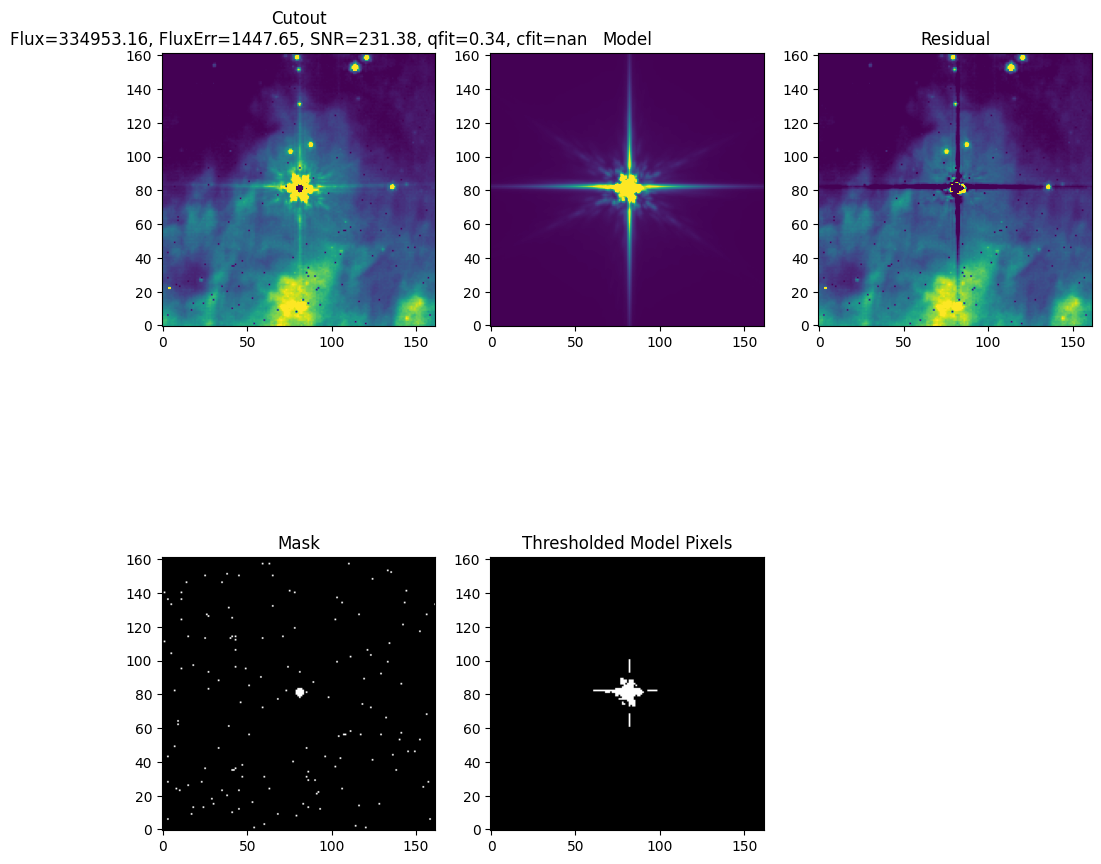

Accepting source 2 with flux=334953.1561151692, fluxerr=1447.6540834469392, snr=231.3765145590778
Source 3: center at (x, y) = (742, 335)
Set x_0.bounds = (80, 82)
Set y_0.bounds = (80, 82)
 id group_id group_size      local_bkg      x_init y_init     flux_init            x_fit             y_fit            flux_fit            x_err              y_err             flux_err     npixfit        qfit       cfit flags             skycoord_fit                 xcentroid         ycentroid    
                                                                                                                                                                                                                                               deg,deg                                                   
--- -------- ---------- ------------------- ------ ------ ------------------ ----------------- ----------------- ----------------- ------------------- ------------------ ----------------- ------- ----------------- 

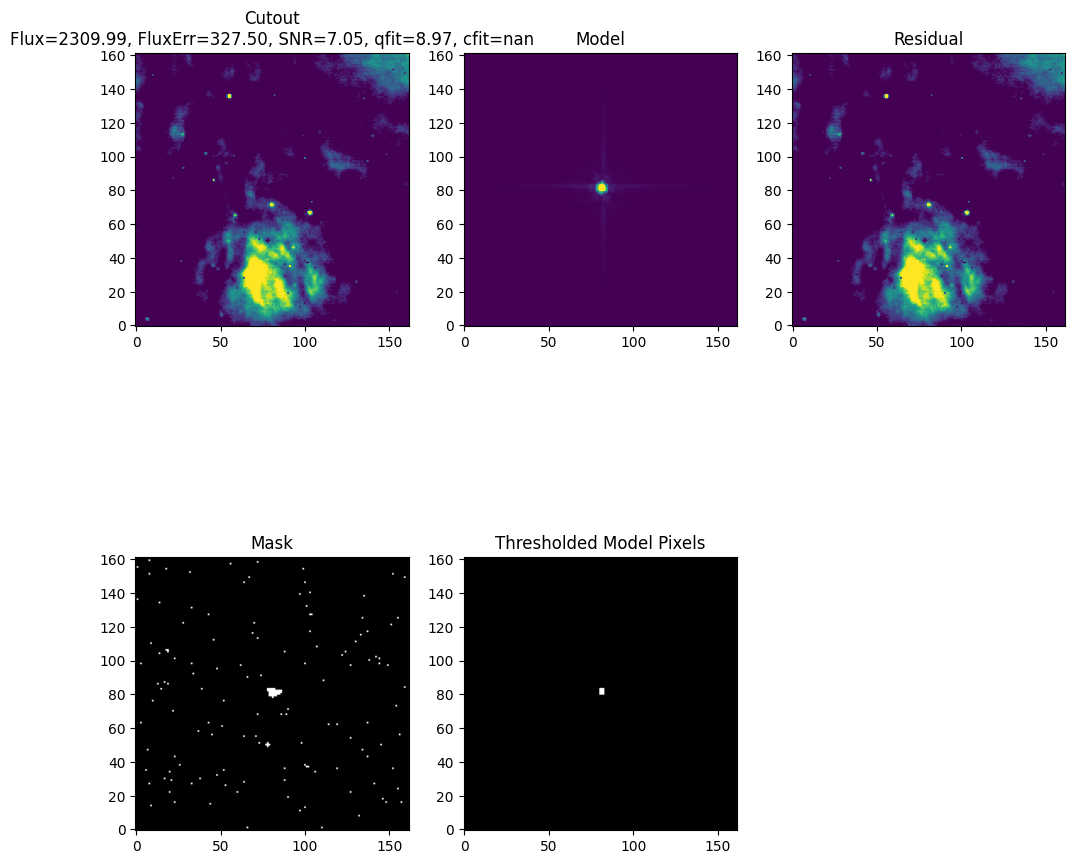

Source 4: center at (x, y) = (1027, 441)
Set x_0.bounds = (79, 83)
Set y_0.bounds = (79, 83)
 id group_id group_size     local_bkg      x_init y_init     flux_init          x_fit            y_fit            flux_fit             x_err               y_err             flux_err     npixfit        qfit        cfit flags             skycoord_fit                 xcentroid          ycentroid    
                                                                                                                                                                                                                                              deg,deg                                                    
--- -------- ---------- ------------------ ------ ------ ----------------- ---------------- ---------------- ------------------ ------------------- ------------------- ----------------- ------- ------------------ ---- ----- ------------------------------------ ------------------ -----------------
  1        1 

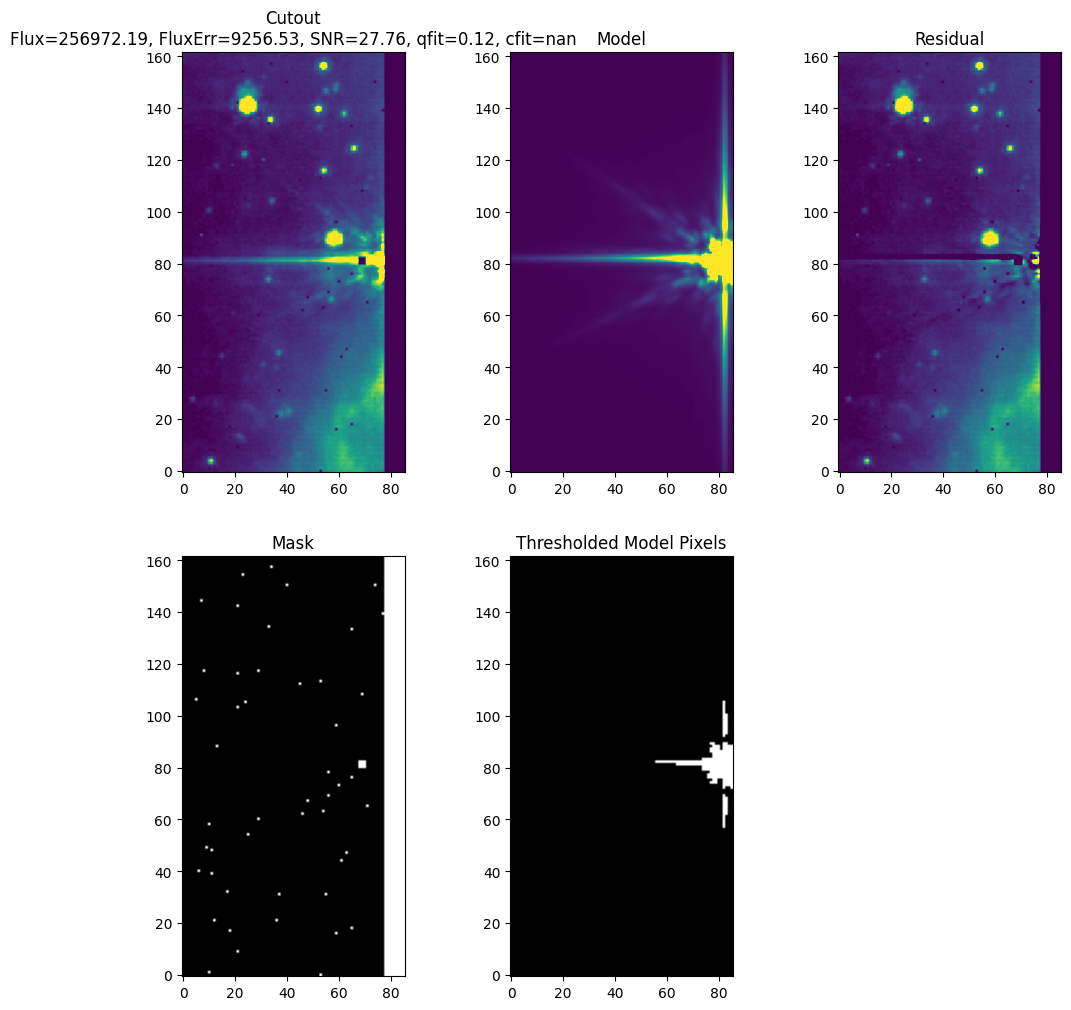

Accepting source 4 with flux=256972.19034099593, fluxerr=9256.533139430534, snr=27.761170026644013


2025-11-12 16:16:36,511 - stpipe - WARNING - MergeConflictWarning: Cannot merge meta key 'date' types <class 'str'> and <class 'str'>, choosing date='2025-11-12 16:16:35 EST'


Source 5: center at (x, y) = (816, 470)
Set x_0.bounds = (80, 82)
Set y_0.bounds = (80, 82)
 id group_id group_size     local_bkg     x_init y_init     flux_init            x_fit             y_fit             flux_fit             x_err              y_err             flux_err     npixfit         qfit        cfit flags             skycoord_fit                xcentroid         ycentroid     
                                                                                                                                                                                                                                                 deg,deg                                                   
--- -------- ---------- ----------------- ------ ------ ------------------ ----------------- ----------------- ------------------- ------------------- ------------------ ----------------- ------- ------------------- ---- ----- ----------------------------------- ----------------- ------------------
  1     

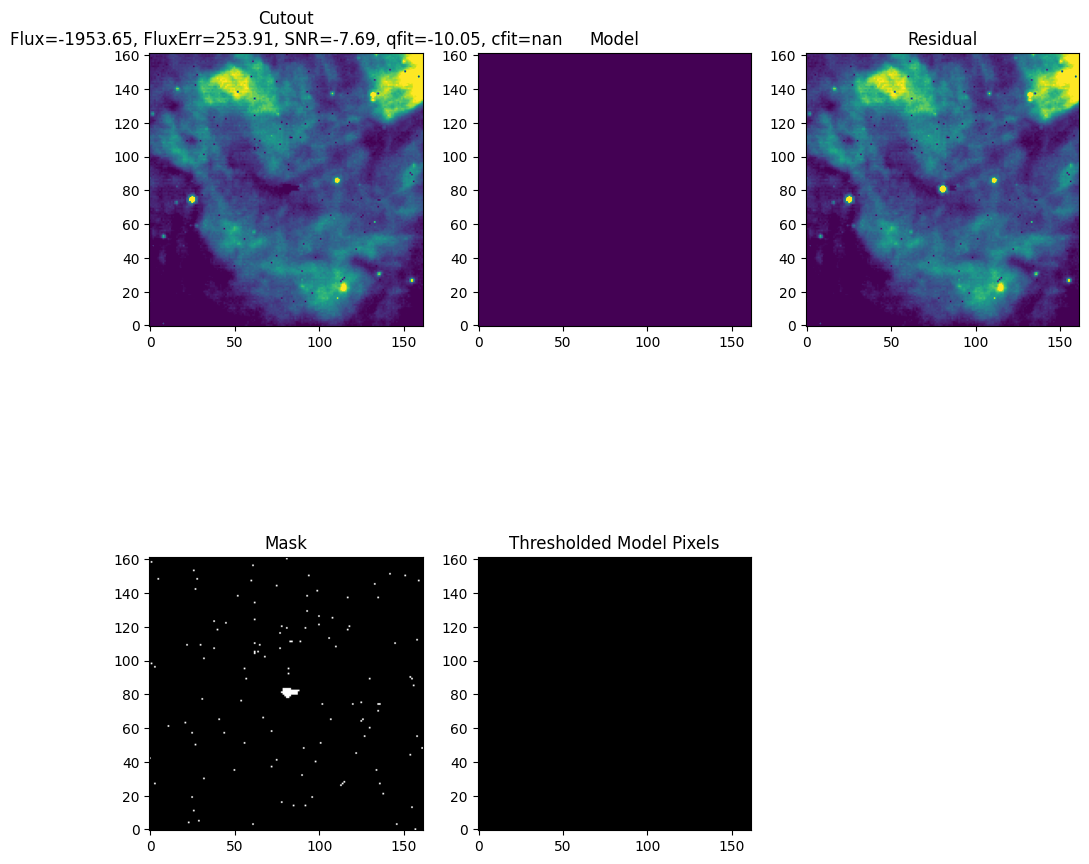

Source 6: center at (x, y) = (685, 501)
Set x_0.bounds = (80, 82)
Set y_0.bounds = (80, 82)
 id group_id group_size    local_bkg     x_init y_init     flux_init           x_fit             y_fit            flux_fit             x_err                 y_err              flux_err      npixfit         qfit        cfit flags              skycoord_fit                 xcentroid         ycentroid    
                                                                                                                                                                                                                                                    deg,deg                                                   
--- -------- ---------- ---------------- ------ ------ ----------------- ----------------- ----------------- ------------------ -------------------- --------------------- ------------------ ------- ------------------- ---- ----- ------------------------------------- ----------------- -----------------

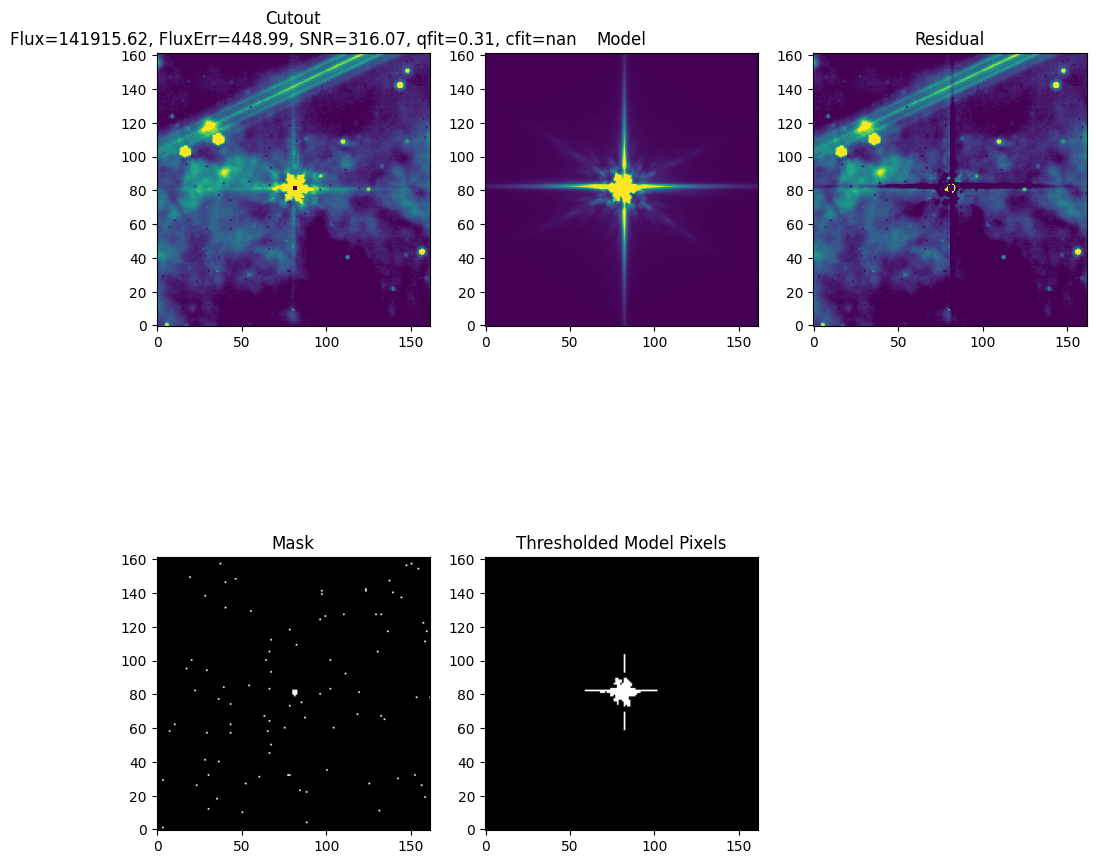

Accepting source 6 with flux=141915.62202410933, fluxerr=448.99483158282965, snr=316.07406598382863


2025-11-12 16:16:38,688 - stpipe - WARNING - MergeConflictWarning: Cannot merge meta key 'date' types <class 'str'> and <class 'str'>, choosing date='2025-11-12 16:16:38 EST'


Source 7: center at (x, y) = (781, 671)
Set x_0.bounds = (78, 84)
Set y_0.bounds = (78, 84)
 id group_id group_size     local_bkg      x_init y_init     flux_init           x_fit             y_fit            flux_fit            x_err               y_err             flux_err     npixfit        qfit        cfit flags             skycoord_fit                xcentroid         ycentroid    
                                                                                                                                                                                                                                               deg,deg                                                  
--- -------- ---------- ------------------ ------ ------ ----------------- ----------------- ----------------- ------------------ ------------------ ------------------- ----------------- ------- ------------------ ---- ----- ----------------------------------- ----------------- -----------------
  1        1     

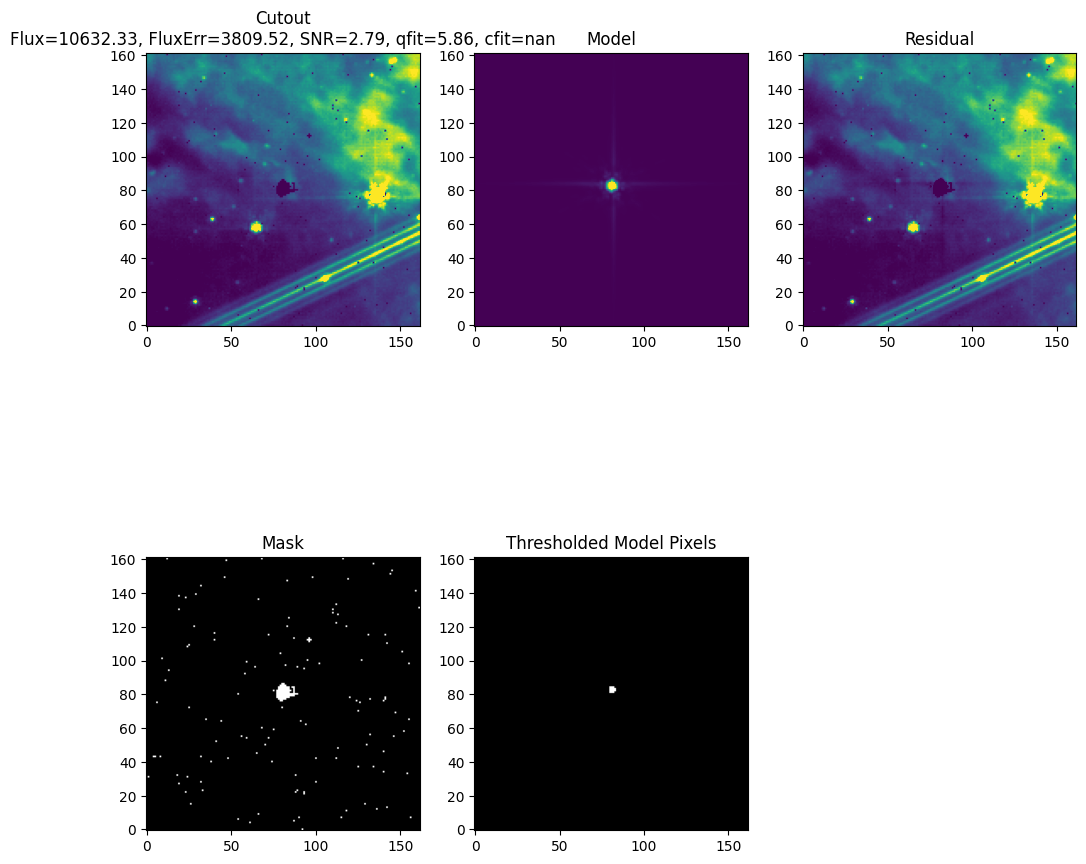

Finished get_saturated_stars


2025-11-12 16:16:39,741 - stpipe - WARNING - Attribute `version` of type <class 'dict'> cannot be added to FITS Header - skipping
2025-11-12 16:16:39,743 - stpipe - WARNING - VerifyWarning: Keyword name 'fit_shape' is greater than 8 characters or contains characters not allowed by the FITS standard; a HIERARCH card will be created.
2025-11-12 16:16:39,749 - stpipe - WARNING - Attribute `fit_shape` of type <class 'numpy.ndarray'> cannot be added to FITS Header - skipping
2025-11-12 16:16:39,751 - stpipe - WARNING - VerifyWarning: Keyword name 'fitter_maxiters' is greater than 8 characters or contains characters not allowed by the FITS standard; a HIERARCH card will be created.
2025-11-12 16:16:39,753 - stpipe - WARNING - VerifyWarning: Keyword name 'aperture_radius' is greater than 8 characters or contains characters not allowed by the FITS standard; a HIERARCH card will be created.
2025-11-12 16:16:39,754 - stpipe - WARNING - VerifyWarning: Keyword name 'progress_bar' is greater than 8


/orange/adamginsburg/jwst/w51/F560W/pipeline/jw06151-o002_t001_miri_f560w_1_o002_crf.fits

/orange/adamginsburg/jwst/w51/F560W/pipeline/jw06151-o002_t001_miri_f560w_4_o002_crf.fits

/orange/adamginsburg/jwst/w51/F560W/pipeline/jw06151-o002_t001_miri_f560w_13_o002_crf.fits

/orange/adamginsburg/jwst/w51/F560W/pipeline/jw06151-o002_t001_miri_f560w_3_o002_crf.fits

/orange/adamginsburg/jwst/w51/F560W/pipeline/jw06151-o002_t001_miri_f560w_6_o002_crf.fits

/orange/adamginsburg/jwst/w51/F560W/pipeline/jw06151-o002_t001_miri_f560w_9_o002_crf.fits

/orange/adamginsburg/jwst/w51/F560W/pipeline/jw06151-o002_t001_miri_f560w_8_o002_crf.fits

/orange/adamginsburg/jwst/w51/F560W/pipeline/jw06151-o002_t001_miri_f560w_14_o002_crf.fits

/orange/adamginsburg/jwst/w51/F560W/pipeline/jw06151-o002_t001_miri_f560w_7_o002_crf.fits

/orange/adamginsburg/jwst/w51/F560W/pipeline/jw06151-o002_t001_miri_f560w_2_o002_crf.fits

/orange/adamginsburg/jwst/w51/F560W/pipeline/jw06151-o002_t001_miri_f560w_11_o002_crf.f

In [33]:
for filter in nircam_filters:
    print()
    print(f"Processing filter {filter}", flush=True)
    main(filt=filter)